In [2]:
# Load the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
#Load the Fear & Greed Dataset
fg = pd.read_csv(r'C:\Users\sanch\Downloads\fear_greed_index.csv')
print(fg.shape)
print(fg.head())

(2644, 4)
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [4]:
#Load the Historical Trader Data
tr = pd.read_csv(r'C:\Users\sanch\Downloads\historical_data.csv')
print(tr.shape)
print(tr.head()) 

(211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

In [5]:
#Clean the Column Names
tr.columns = tr.columns.str.strip().str.lower().str.replace(' ', '_')
print(tr.columns.tolist())

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']


In [6]:
# Converting 'timestamp_ist' column to a proper date format
# The timestamp looks like '02-12-2024 22:50' so we extract just the date part

tr['date'] = pd.to_datetime(tr['timestamp_ist'], dayfirst=True).dt.normalize()

print(tr['date'].head(10))
print("Date range:", tr['date'].min(), "→", tr['date'].max())

0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
5   2024-12-02
6   2024-12-02
7   2024-12-02
8   2024-12-02
9   2024-12-02
Name: date, dtype: datetime64[us]
Date range: 2023-05-01 00:00:00 → 2025-05-01 00:00:00


In [7]:
# Converting the 'date' column in Fear & Greed data to the same date format
# This is necessary so both datasets speak the same "date language"
# Only then can we correctly join/merge them together

fg['date'] = pd.to_datetime(fg['date'])

print(fg['date'].head())
print("Date range:", fg['date'].min(), "→", fg['date'].max())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]
Date range: 2018-02-01 00:00:00 → 2025-05-02 00:00:00


In [8]:
# Merging the trader data with Fear & Greed data using 'date' as the common key
# This adds a sentiment column to every trade row
# So each trade will now know what the market mood was on that day
# 'left' merge means we keep all trader data even if no sentiment found for that date

merged = tr.merge(
    fg[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print("Merged shape:", merged.shape)
print("Trades with sentiment tag:", merged['classification'].notna().sum())
print("Trades WITHOUT sentiment tag:", merged['classification'].isna().sum())
print(merged[['date', 'account', 'coin', 'closed_pnl', 'classification']].head())

Merged shape: (211224, 19)
Trades with sentiment tag: 211218
Trades WITHOUT sentiment tag: 6
        date                                     account  coin  closed_pnl  \
0 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
1 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
2 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
3 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
4 2024-12-02  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   

  classification  
0  Extreme Greed  
1  Extreme Greed  
2  Extreme Greed  
3  Extreme Greed  
4  Extreme Greed  


In [9]:
# Removing the 6 rows that didn't get a sentiment tag
# These 6 trades fall outside the Fear & Greed date range

merged = merged.dropna(subset=['classification'])

print("Final usable rows:", len(merged))
print("Sentiment distribution:")
print(merged['classification'].value_counts())

Final usable rows: 211218
Sentiment distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [10]:
# Grouping all trades by sentiment category
# Calculating total PnL, average PnL and number of trades for each sentiment
# This tells us — in which market mood do traders make the most money?

pnl_by_sentiment = merged.groupby('classification')['closed_pnl'].agg(
    total_pnl='sum',
    avg_pnl='mean',
    num_trades='count'
).reset_index()

# Ordering from most fearful to most greedy
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pnl_by_sentiment['classification'] = pd.Categorical(pnl_by_sentiment['classification'], categories=order, ordered=True)
pnl_by_sentiment = pnl_by_sentiment.sort_values('classification')

print(pnl_by_sentiment.to_string(index=False))

classification    total_pnl   avg_pnl  num_trades
  Extreme Fear 7.391102e+05 34.537862       21400
          Fear 3.357155e+06 54.290400       61837
       Neutral 1.292921e+06 34.307718       37686
         Greed 2.150129e+06 42.743559       50303
 Extreme Greed 2.715171e+06 67.892861       39992


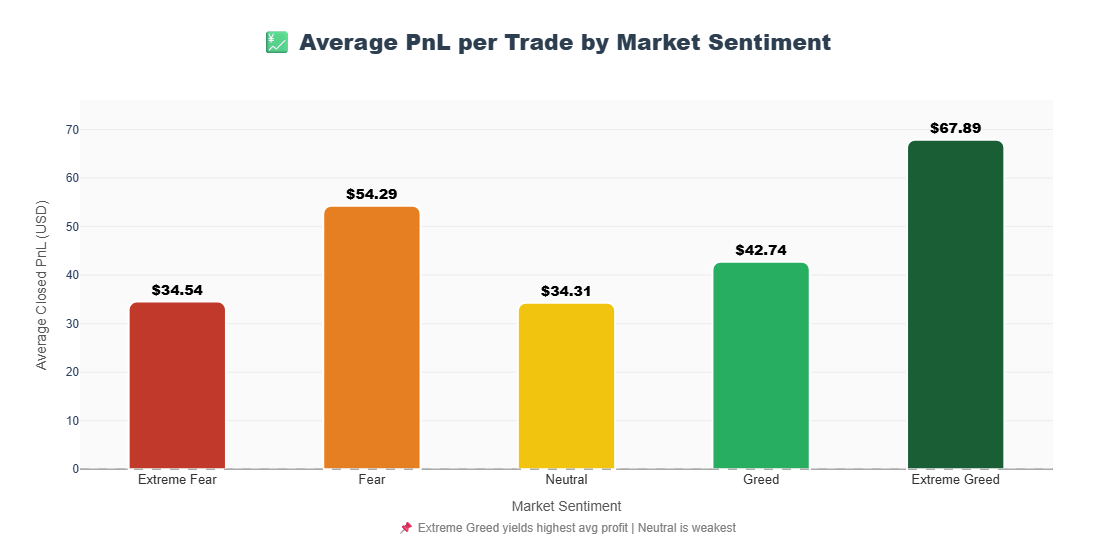

In [13]:
# Using Plotly to create an interactive bar chart
# Colors go from red (Extreme Fear) to dark green (Extreme Greed)

import plotly.graph_objects as go

sentiments = pnl_by_sentiment['classification'].tolist()
values = pnl_by_sentiment['avg_pnl'].tolist()
colors = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#1a5e36']

fig = go.Figure(go.Bar(
    x=sentiments,
    y=values,
    marker=dict(
        color=colors,
        line=dict(color='white', width=2),
        cornerradius=8
    ),
    text=[f'${v:.2f}' for v in values],
    textposition='outside',
    textfont=dict(size=14, color='black', family='Arial Black'),
    width=0.5
))

fig.update_layout(
    title=dict(
        text='💹 Average PnL per Trade by Market Sentiment',
        font=dict(size=22, family='Arial Black', color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Market Sentiment', font=dict(size=14, color='#555')),
        tickfont=dict(size=13, family='Arial', color='#333'),
        showgrid=False
    ),
    yaxis=dict(
        title=dict(text='Average Closed PnL (USD)', font=dict(size=14, color='#555')),
        tickfont=dict(size=12),
        showgrid=True,
        gridcolor='#ececec',
        gridwidth=1,
        zeroline=True,
        zerolinecolor='#aaa',
        zerolinewidth=1.5
    ),
    plot_bgcolor='#fafafa',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    height=550,
    margin=dict(t=100, b=80, l=80, r=40),
    showlegend=False,
    annotations=[
        dict(
            text='📌 Extreme Greed yields highest avg profit | Neutral is weakest',
            xref='paper', yref='paper',
            x=0.5, y=-0.18,
            showarrow=False,
            font=dict(size=12, color='gray'),
            xanchor='center'
        )
    ]
)

fig.add_hline(y=0, line_dash='dash', line_color='#aaa', line_width=1.5)
fig.show()
fig.write_html('chart1_avg_pnl_by_sentiment.html')

In [14]:
# Win rate = percentage of trades that made a PROFIT (closed_pnl > 0)
# This tells us — in which market mood do traders WIN more often?
# A trade is a 'win' if closed_pnl is greater than 0

merged['is_win'] = merged['closed_pnl'] > 0

win_rate = merged.groupby('classification')['is_win'].mean().reset_index()
win_rate.columns = ['classification', 'win_rate']

# Order from Extreme Fear to Extreme Greed
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
win_rate['classification'] = pd.Categorical(win_rate['classification'], categories=order, ordered=True)
win_rate = win_rate.sort_values('classification')
win_rate['win_rate_pct'] = (win_rate['win_rate'] * 100).round(2)

print(win_rate.to_string(index=False))

classification  win_rate  win_rate_pct
  Extreme Fear  0.370607         37.06
          Fear  0.420768         42.08
       Neutral  0.396991         39.70
         Greed  0.384828         38.48
 Extreme Greed  0.464943         46.49


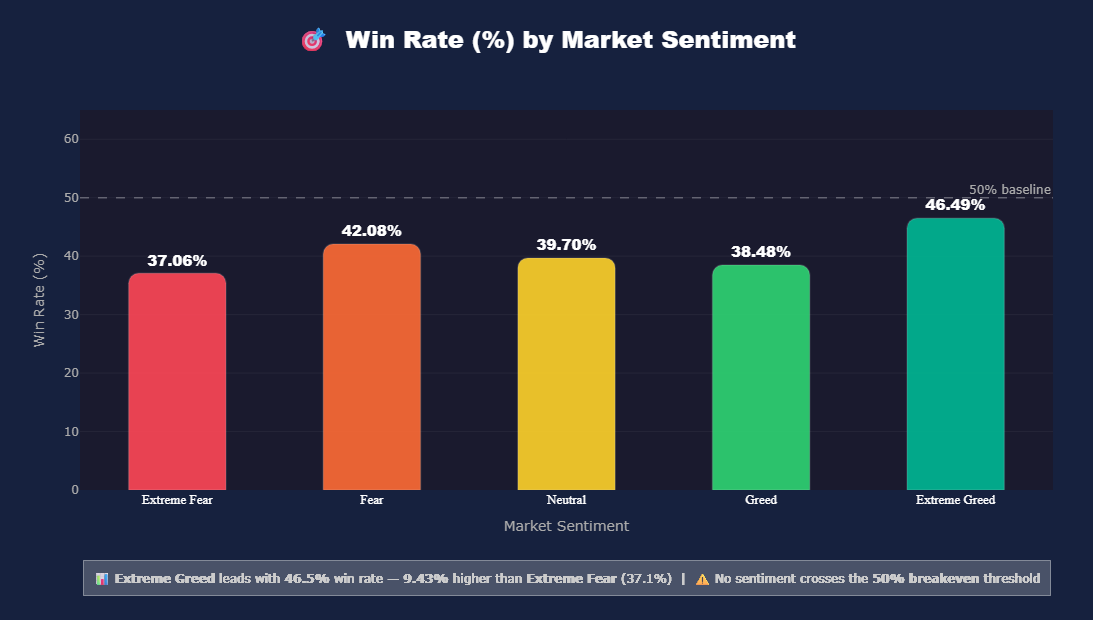

In [20]:
# Visualizing win rate across different sentiment categories
# The 50% dashed line acts as a reference — above it means more wins than losses
# Helps us understand in which mood traders are most consistently profitable

import plotly.graph_objects as go
import numpy as np

sentiments = win_rate['classification'].tolist()
values = win_rate['win_rate_pct'].tolist()
colors = ['#ff4757', '#ff6b35', '#ffd32a', '#2ed573', '#00b894']
emojis = ['😨', '😟', '😐', '😊', '🤑']

# Dynamic insight text generated from actual data
best_sent = sentiments[values.index(max(values))]
worst_sent = sentiments[values.index(min(values))]
best_val = max(values)
worst_val = min(values)
diff = round(best_val - worst_val, 2)

insight_text = (
    f'📊 <b>{best_sent}</b> leads with <b>{best_val:.1f}%</b> win rate — '
    f'<b>{diff}%</b> higher than <b>{worst_sent}</b> ({worst_val:.1f}%) &nbsp;|&nbsp; '
    f'⚠️ No sentiment crosses the <b>50% breakeven</b> threshold'
)

fig = go.Figure()

for sent, val, col, emoji in zip(sentiments, values, colors, emojis):
    fig.add_trace(go.Bar(
        x=[sent],
        y=[val],
        name=sent,
        marker=dict(
            color=col,
            line=dict(color='rgba(255,255,255,0.15)', width=1.5),
            cornerradius=10,
            opacity=0.9
        ),
        text=f'<b>{val:.2f}%</b>',
        textposition='outside',
        textfont=dict(size=15, color='white', family='Arial Black'),
        width=0.5,
        # Emoji shown on hover
        hovertemplate=(
            f'<b style="font-size:20px">{emoji}</b><br>'
            f'<b>{sent}</b><br>'
            f'Win Rate: <b>{val:.2f}%</b><br>'
            f'Gap to 50%: <b>{50 - val:.2f}%</b>'
            '<extra></extra>'
        ),
        showlegend=False
    ))

# Static emoji annotations above each bar
for sent, val, emoji in zip(sentiments, values, emojis):
    fig.add_annotation(
        x=sent, y=val + 3,
        text=emoji,
        showarrow=False,
        font=dict(size=24),
        xanchor='center'
    )

fig.update_layout(
    title=dict(
        text='🎯  Win Rate (%) by Market Sentiment',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5,
        xanchor='center',
        y=0.95
    ),
    xaxis=dict(
        title=dict(text='Market Sentiment', font=dict(size=14, color='#aaa')),
        tickfont=dict(size=13, family='Arial Bold', color='white'),
        showgrid=False,
        zeroline=False,
        categoryorder='array',
        categoryarray=sentiments
    ),
    yaxis=dict(
        title=dict(text='Win Rate (%)', font=dict(size=14, color='#aaa')),
        tickfont=dict(size=12, color='#aaa'),
        showgrid=True,
        gridcolor='rgba(255,255,255,0.05)',
        gridwidth=1,
        zeroline=False,
        range=[0, 65]
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=620,
    margin=dict(t=110, b=130, l=80, r=40),
    showlegend=False,
    hoverlabel=dict(
        bgcolor='#0f3460',
        font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.28,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1,
            borderpad=10
        )
    ]
)

# 50% reference line
fig.add_hline(
    y=50,
    line_dash='dash',
    line_color='rgba(255,255,255,0.3)',
    line_width=1.5,
    annotation_text='50% baseline',
    annotation_font_color='#aaa',
    annotation_position='top right'
)

fig.show()
fig.write_html('chart2_winrate_by_sentiment.html')

In [21]:
# Calculating total and average trading volume for each sentiment
# This tells us — in which market mood do traders trade the MOST?
# High volume = traders are more active and confident in that sentiment

volume_by_sentiment = merged.groupby('classification')['size_usd'].agg(
    total_volume='sum',
    avg_volume='mean',
    num_trades='count'
).reset_index()

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
volume_by_sentiment['classification'] = pd.Categorical(
    volume_by_sentiment['classification'], categories=order, ordered=True
)
volume_by_sentiment = volume_by_sentiment.sort_values('classification')

print(volume_by_sentiment.to_string(index=False))

classification  total_volume  avg_volume  num_trades
  Extreme Fear  114484261.44 5349.731843       21400
          Fear  483324789.79 7816.109931       61837
       Neutral  180242063.08 4782.732661       37686
         Greed  288582494.72 5736.884375       50303
 Extreme Greed  124465164.57 3112.251565       39992


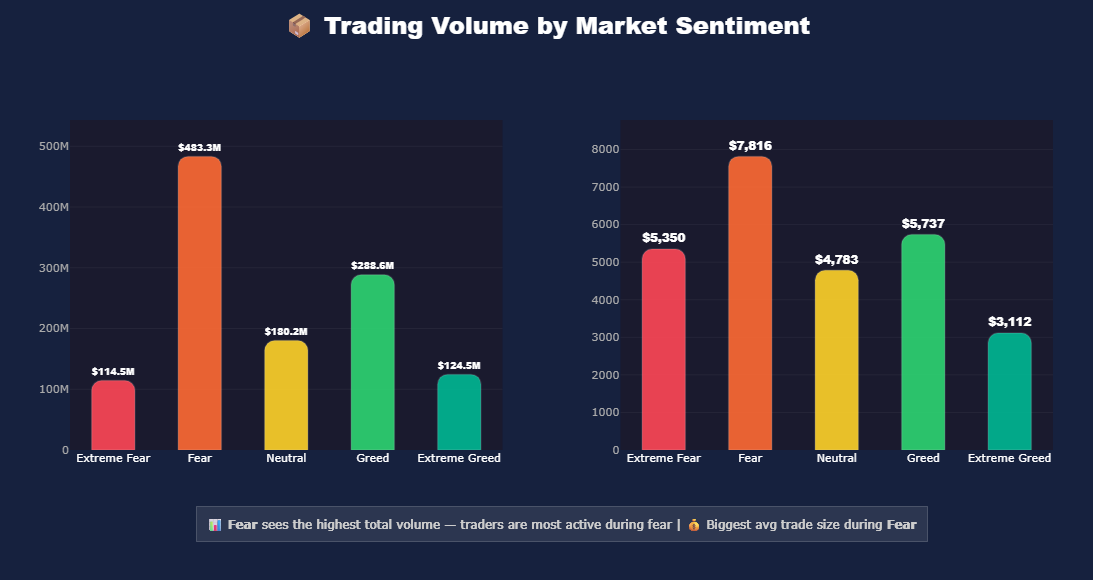

In [23]:
# Visualizing trading volume across sentiments
# Two charts side by side — total volume and average trade size
# This reveals HOW MUCH traders are putting at risk in each sentiment

import plotly.graph_objects as go
from plotly.subplots import make_subplots

sentiments = volume_by_sentiment['classification'].tolist()
total_vol = volume_by_sentiment['total_volume'].tolist()
avg_vol = volume_by_sentiment['avg_volume'].tolist()
colors = ['#ff4757', '#ff6b35', '#ffd32a', '#2ed573', '#00b894']
emojis = ['😨', '😟', '😐', '😊', '🤑']

# Dynamic insight text
best_total = sentiments[total_vol.index(max(total_vol))]
best_avg = sentiments[avg_vol.index(max(avg_vol))]

insight_text = (
    f'📊 <b>{best_total}</b> sees the highest total volume — '
    f'traders are most active during fear | '
    f'💰 Biggest avg trade size during <b>{best_avg}</b>'
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '<b>Total Trading Volume (USD)</b>',
        '<b>Average Trade Size (USD)</b>'
    ],
    horizontal_spacing=0.12
)

# Chart 1 — Total Volume
for sent, val, col, emoji in zip(sentiments, total_vol, colors, emojis):
    fig.add_trace(go.Bar(
        x=[sent], y=[val],
        marker=dict(color=col, cornerradius=10, opacity=0.9,
                    line=dict(color='rgba(255,255,255,0.15)', width=1.5)),
        text=f'<b>${val/1e6:.1f}M</b>',
        textposition='outside',
        textfont=dict(size=13, color='white', family='Arial Black'),
        width=0.5,
        hovertemplate=f'{emoji} <b>{sent}</b><br>Total Volume: $%{{y:,.0f}}<extra></extra>',
        showlegend=False
    ), row=1, col=1)

# Chart 2 — Avg Trade Size
for sent, val, col, emoji in zip(sentiments, avg_vol, colors, emojis):
    fig.add_trace(go.Bar(
        x=[sent], y=[val],
        marker=dict(color=col, cornerradius=10, opacity=0.9,
                    line=dict(color='rgba(255,255,255,0.15)', width=1.5)),
        text=f'<b>${val:,.0f}</b>',
        textposition='outside',
        textfont=dict(size=13, color='white', family='Arial Black'),
        width=0.5,
        hovertemplate=f'{emoji} <b>{sent}</b><br>Avg Trade Size: $%{{y:,.0f}}<extra></extra>',
        showlegend=False
    ), row=1, col=2)

fig.update_layout(
    title=dict(
        text='📦 Trading Volume by Market Sentiment',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.97
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=580,
    margin=dict(t=120, b=130, l=70, r=40),
    showlegend=False,
    hoverlabel=dict(
        bgcolor='#0f3460', font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.28,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

# Style both x and y axes
for col in [1, 2]:
    fig.update_xaxes(
        tickfont=dict(size=11, color='white'),
        showgrid=False, zeroline=False,
        categoryorder='array', categoryarray=sentiments,
        row=1, col=col
    )
    fig.update_yaxes(
        tickfont=dict(size=11, color='#aaa'),
        showgrid=True, gridcolor='rgba(255,255,255,0.05)',
        zeroline=False, row=1, col=col
    )

fig.show()
fig.write_html('chart3_volume_by_sentiment.html')

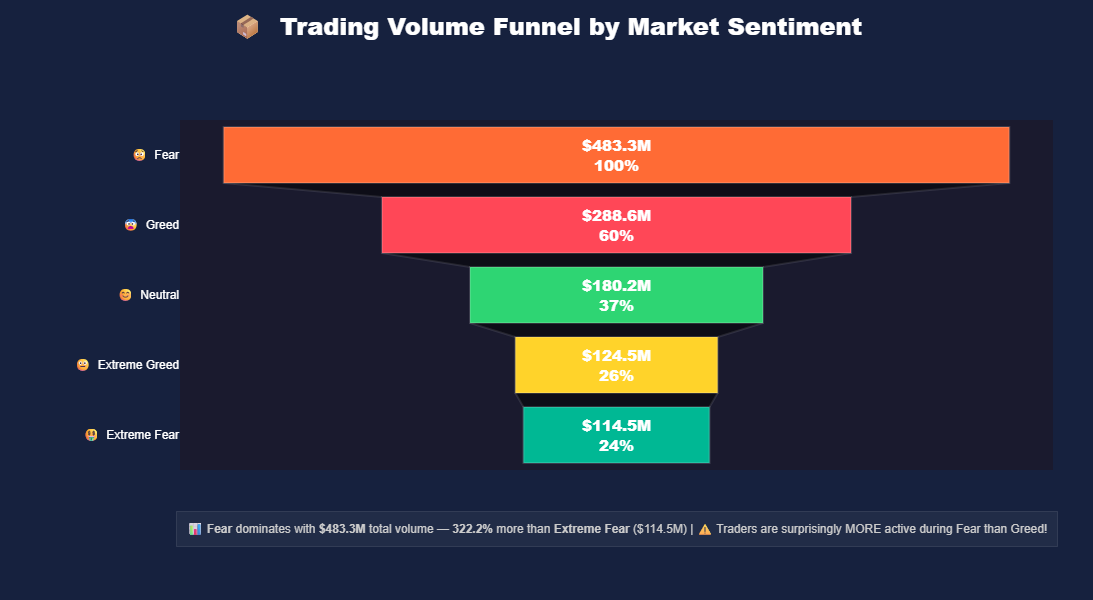

In [25]:
# Funnel chart shows trading volume across sentiments in a visually striking way
# Wider = more volume, Narrower = less volume
# Sorted from highest to lowest so the funnel shape is clear

import plotly.graph_objects as go

# Sort by total volume descending for proper funnel shape
vol_sorted = volume_by_sentiment.sort_values('total_volume', ascending=False)
sentiments_f = vol_sorted['classification'].tolist()
total_vol_f = vol_sorted['total_volume'].tolist()
colors_f = ['#ff6b35', '#ff4757', '#2ed573', '#ffd32a', '#00b894']
emojis_f = ['😟', '😨', '😊', '😐', '🤑']

# Dynamic insight
top = sentiments_f[0]
bottom = sentiments_f[-1]
top_val = total_vol_f[0]
bottom_val = total_vol_f[-1]
diff_pct = round((top_val - bottom_val) / bottom_val * 100, 1)

insight_text = (
    f'📊 <b>{top}</b> dominates with <b>${top_val/1e6:.1f}M</b> total volume — '
    f'<b>{diff_pct}%</b> more than <b>{bottom}</b> (${bottom_val/1e6:.1f}M) | '
    f'⚠️ Traders are surprisingly MORE active during Fear than Greed!'
)

fig = go.Figure(go.Funnel(
    y=[f'{e}  {s}' for e, s in zip(emojis_f, sentiments_f)],
    x=total_vol_f,
    textinfo='value+percent initial',
    texttemplate=[f'<b>${v/1e6:.1f}M</b><br>%{{percentInitial}}' for v in total_vol_f],
    textfont=dict(size=15, color='white', family='Arial Black'),
    marker=dict(
        color=colors_f,
        line=dict(color='rgba(255,255,255,0.15)', width=2)
    ),
    hovertemplate='<b>%{y}</b><br>Volume: $%{x:,.0f}<extra></extra>',
    connector=dict(
        line=dict(color='rgba(255,255,255,0.1)', width=2)
    )
))

fig.update_layout(
    title=dict(
        text='📦  Trading Volume Funnel by Market Sentiment',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.97
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=600,
    margin=dict(t=120, b=130, l=180, r=40),
    font=dict(family='Arial, sans-serif', color='white'),
    hoverlabel=dict(
        bgcolor='#0f3460', font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.22,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.show()
fig.write_html('chart3_volume_by_sentiment.html')

In [26]:
# Analyzing whether traders prefer to BUY or SELL in each sentiment
# This reveals trader psychology — do they buy more when market is fearful?
# Or do they sell more when market is greedy?

buy_sell = merged.groupby(['classification', 'side']).size().reset_index(name='count')

# Calculate percentage within each sentiment
buy_sell['total'] = buy_sell.groupby('classification')['count'].transform('sum')
buy_sell['percentage'] = (buy_sell['count'] / buy_sell['total'] * 100).round(2)

# Order sentiments
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
buy_sell['classification'] = pd.Categorical(buy_sell['classification'], categories=order, ordered=True)
buy_sell = buy_sell.sort_values(['classification', 'side'])

print(buy_sell.to_string(index=False))

classification side  count  total  percentage
  Extreme Fear  BUY  10935  21400       51.10
  Extreme Fear SELL  10465  21400       48.90
          Fear  BUY  30270  61837       48.95
          Fear SELL  31567  61837       51.05
       Neutral  BUY  18969  37686       50.33
       Neutral SELL  18717  37686       49.67
         Greed  BUY  24576  50303       48.86
         Greed SELL  25727  50303       51.14
 Extreme Greed  BUY  17940  39992       44.86
 Extreme Greed SELL  22052  39992       55.14


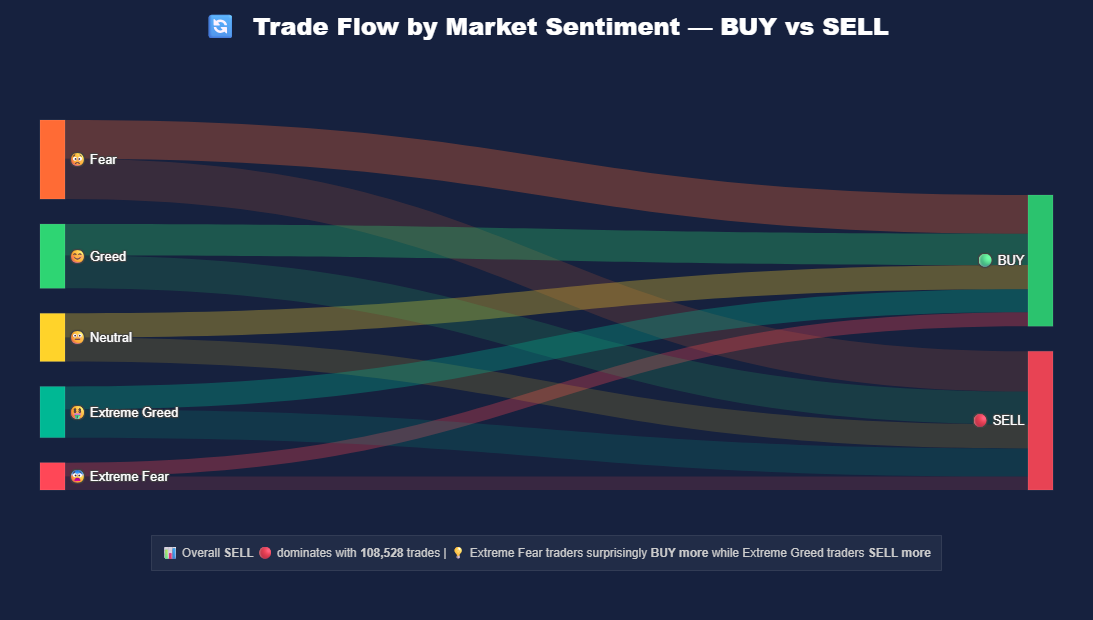

In [28]:
# Sankey diagram shows the FLOW from each sentiment → BUY or SELL
# Width of each flow = volume of trades
# This beautifully shows how trading behaviour shifts across sentiments

import plotly.graph_objects as go

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
emojis = ['😨', '😟', '😐', '😊', '🤑']

# Node labels — left side = sentiments, right side = BUY/SELL
node_labels = [f'{e} {s}' for e, s in zip(emojis, order)] + ['🟢 BUY', '🔴 SELL']

# Node colors
node_colors = [
    '#ff4757',   # Extreme Fear
    '#ff6b35',   # Fear
    '#ffd32a',   # Neutral
    '#2ed573',   # Greed
    '#00b894',   # Extreme Greed
    'rgba(46, 213, 115, 0.9)',   # BUY
    'rgba(255, 71, 87, 0.9)',    # SELL
]

# Build source, target, value lists
sources = []
targets = []
values = []
link_colors = []

buy_colors_transparent = [
    'rgba(255, 71, 87, 0.3)',    # Extreme Fear → BUY
    'rgba(255, 107, 53, 0.3)',   # Fear → BUY
    'rgba(255, 211, 42, 0.3)',   # Neutral → BUY
    'rgba(46, 213, 115, 0.3)',   # Greed → BUY
    'rgba(0, 184, 148, 0.3)',    # Extreme Greed → BUY
]

sell_colors_transparent = [
    'rgba(255, 71, 87, 0.15)',
    'rgba(255, 107, 53, 0.15)',
    'rgba(255, 211, 42, 0.15)',
    'rgba(46, 213, 115, 0.15)',
    'rgba(0, 184, 148, 0.15)',
]

for i, sent in enumerate(order):
    subset = buy_sell[buy_sell['classification'] == sent]
    buy_count = int(subset[subset['side'] == 'BUY']['count'].values[0])
    sell_count = int(subset[subset['side'] == 'SELL']['count'].values[0])

    # sentiment → BUY (index 5)
    sources.append(i)
    targets.append(5)
    values.append(buy_count)
    link_colors.append(buy_colors_transparent[i])

    # sentiment → SELL (index 6)
    sources.append(i)
    targets.append(6)
    values.append(sell_count)
    link_colors.append(sell_colors_transparent[i])

# Dynamic insight
total_buy = sum(values[::2])
total_sell = sum(values[1::2])
dominant = 'BUY 🟢' if total_buy > total_sell else 'SELL 🔴'
insight_text = (
    f'📊 Overall <b>{dominant}</b> dominates with <b>{max(total_buy, total_sell):,}</b> trades | '
    f'💡 Extreme Fear traders surprisingly <b>BUY more</b> while Extreme Greed traders <b>SELL more</b>'
)

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        pad=25,
        thickness=25,
        line=dict(color='rgba(255,255,255,0.1)', width=1),
        label=node_labels,
        color=node_colors,
        hovertemplate='<b>%{label}</b><br>Total Trades: %{value:,}<extra></extra>'
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
        hovertemplate='<b>%{source.label}</b> → <b>%{target.label}</b><br>Trades: %{value:,}<extra></extra>'
    )
))

fig.update_layout(
    title=dict(
        text='🔄  Trade Flow by Market Sentiment — BUY vs SELL',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.97
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=620,
    margin=dict(t=120, b=130, l=40, r=40),
    font=dict(family='Arial, sans-serif', color='white', size=13),
    hoverlabel=dict(
        bgcolor='#0f3460', font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.22,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.show()
fig.write_html('chart4_buysell_sankey.html')

In [29]:
# Finding the top performing traders by total PnL
# We filter traders with at least 10 trades to remove lucky one-time traders
# This shows us who are the CONSISTENTLY profitable traders

top_traders = merged.groupby('account').agg(
    total_pnl=('closed_pnl', 'sum'),
    avg_pnl=('closed_pnl', 'mean'),
    num_trades=('closed_pnl', 'count'),
    win_rate=('is_win', 'mean')
).reset_index()

# Minimum 10 trades filter
top_traders = top_traders[top_traders['num_trades'] >= 10]
top_traders['win_rate'] = (top_traders['win_rate'] * 100).round(2)
top_traders = top_traders.sort_values('total_pnl', ascending=False).head(15)

print(top_traders[['account', 'total_pnl', 'avg_pnl', 'num_trades', 'win_rate']].to_string(index=False))

                                   account    total_pnl    avg_pnl  num_trades  win_rate
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2.143383e+06 145.481748       14733     33.71
0x083384f897ee0f19899168e3b1bec365f52a9012 1.600230e+06 419.127768        3818     35.96
0xbaaaf6571ab7d571043ff1e313a9609a10637864 9.401638e+05  44.364091       21192     46.76
0x513b8629fe877bb581bf244e326a047b249c4ff1 8.404226e+05  68.684419       12236     40.12
0xbee1707d6b44d4d52bfe19e41f8a828645437aab 8.360806e+05  20.806305       40184     42.82
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4 6.777471e+05 155.589314        4356     48.62
0x72743ae2822edd658c0c50608fd7c5c501b2afbd 4.293556e+05 270.034947        1590     34.59
0x430f09841d65beb3f27765503d0f850b8bce7713 4.165419e+05 336.735548        1237     48.42
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4 3.790954e+05  38.319560        9893     81.09
0x72c6a4624e1dffa724e6d00d64ceae698af892a0 3.605395e+05 253.187858        1424     30.34
0x4f93fead39b70a1824f

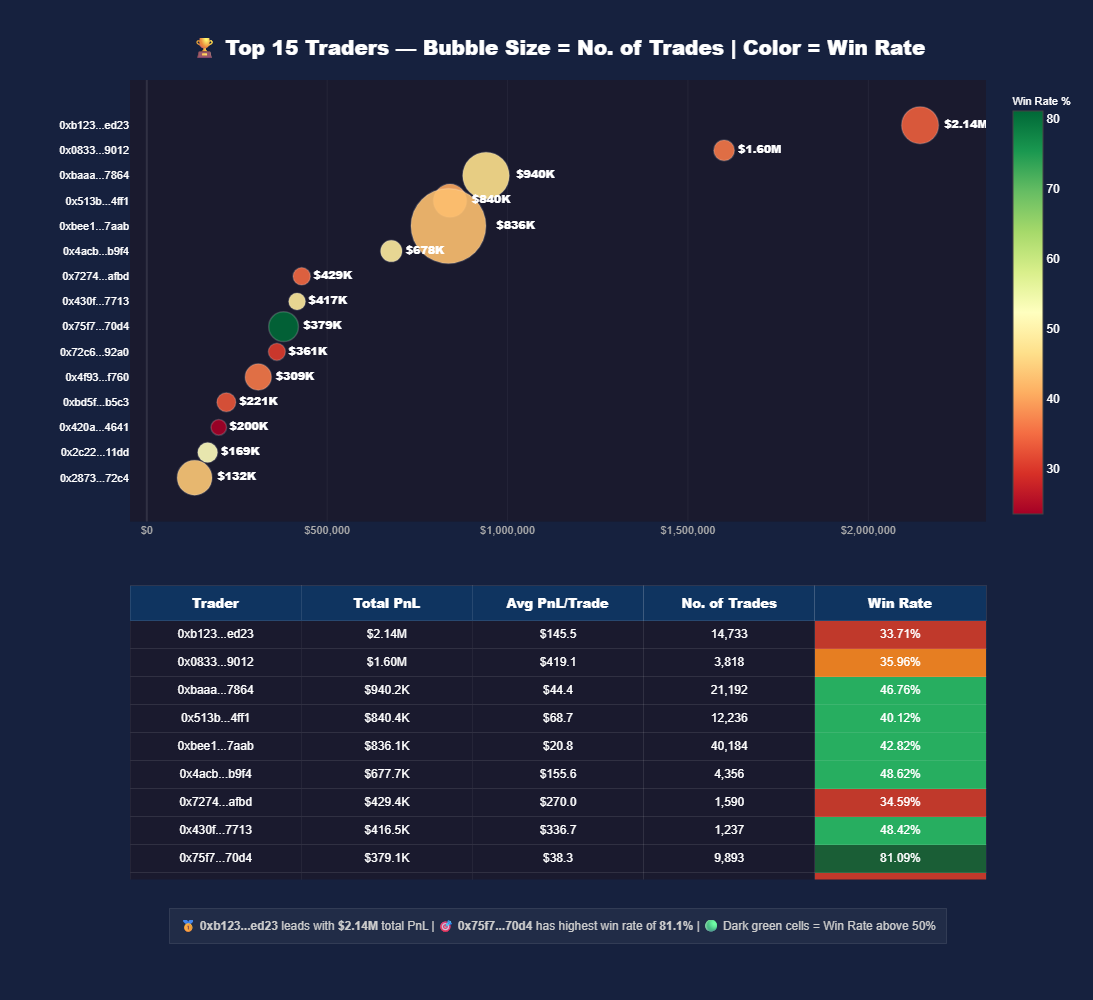

In [31]:
# Combined chart — bubble chart on top + detailed stats table below
# Bubble chart shows visual overview, table shows exact numbers
# Together they give both visual impact AND detailed information

import plotly.graph_objects as go
from plotly.subplots import make_subplots

top_traders['short_acc'] = top_traders['account'].str[:6] + '...' + top_traders['account'].str[-4:]

fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.6, 0.4],
    specs=[[{"type": "scatter"}], [{"type": "table"}]],
    vertical_spacing=0.08,
    subplot_titles=[
        '<b>🏆 Top 15 Traders — Bubble Size = No. of Trades | Color = Win Rate</b>',
        '<b>📋 Detailed Stats Table</b>'
    ]
)

# ── Bubble Chart (top) ──
fig.add_trace(go.Scatter(
    x=top_traders['total_pnl'],
    y=top_traders['short_acc'],
    mode='markers+text',
    marker=dict(
        size=top_traders['num_trades'] / top_traders['num_trades'].max() * 60 + 15,
        color=top_traders['win_rate'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(
            title=dict(text='Win Rate %', font=dict(color='white', size=11)),
            tickfont=dict(color='white'),
            len=0.55,
            y=0.72
        ),
        line=dict(color='rgba(255,255,255,0.2)', width=1.5),
        opacity=0.9
    ),
    text=top_traders['total_pnl'].apply(lambda x: f'${x/1e6:.2f}M' if x >= 1e6 else f'${x/1e3:.0f}K'),
    textposition='middle right',
    textfont=dict(size=11, color='white', family='Arial Black'),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Total PnL: $%{x:,.0f}<br>'
        'Win Rate: %{marker.color:.1f}%<br>'
        '<extra></extra>'
    ),
    showlegend=False
), row=1, col=1)

# ── Stats Table (bottom) ──
# Color code win rate cells
def wr_color(wr):
    if wr >= 50:   return '#1a5e36'
    elif wr >= 40: return '#27ae60'
    elif wr >= 35: return '#e67e22'
    else:          return '#c0392b'

cell_colors_wr = [wr_color(wr) for wr in top_traders['win_rate']]

fig.add_trace(go.Table(
    header=dict(
        values=[
            '<b>Trader</b>',
            '<b>Total PnL</b>',
            '<b>Avg PnL/Trade</b>',
            '<b>No. of Trades</b>',
            '<b>Win Rate</b>'
        ],
        fill_color='#0f3460',
        font=dict(color='white', size=13, family='Arial Black'),
        align='center',
        height=35,
        line=dict(color='rgba(255,255,255,0.1)', width=1)
    ),
    cells=dict(
        values=[
            top_traders['short_acc'],
            top_traders['total_pnl'].apply(lambda x: f'${x/1e6:.2f}M' if x >= 1e6 else f'${x/1e3:.1f}K'),
            top_traders['avg_pnl'].apply(lambda x: f'${x:,.1f}'),
            top_traders['num_trades'].apply(lambda x: f'{x:,}'),
            top_traders['win_rate'].apply(lambda x: f'{x:.2f}%')
        ],
        fill_color=[
            ['#1a1a2e'] * len(top_traders),
            ['#1a1a2e'] * len(top_traders),
            ['#1a1a2e'] * len(top_traders),
            ['#1a1a2e'] * len(top_traders),
            cell_colors_wr
        ],
        font=dict(color='white', size=12, family='Arial'),
        align='center',
        height=28,
        line=dict(color='rgba(255,255,255,0.05)', width=1)
    )
), row=2, col=1)

# Dynamic insight
best = top_traders.iloc[0]
best_wr = top_traders.loc[top_traders['win_rate'].idxmax()]
insight_text = (
    f'🥇 <b>{best["short_acc"]}</b> leads with <b>${best["total_pnl"]/1e6:.2f}M</b> total PnL | '
    f'🎯 <b>{best_wr["short_acc"]}</b> has highest win rate of <b>{best_wr["win_rate"]:.1f}%</b> | '
    f'🟢 Dark green cells = Win Rate above 50%'
)

fig.update_layout(
    paper_bgcolor='#16213e',
    plot_bgcolor='#1a1a2e',
    height=1000,
    margin=dict(t=80, b=120, l=130, r=100),
    font=dict(family='Arial, sans-serif', color='white'),
    hoverlabel=dict(
        bgcolor='#0f3460', font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text='🏆 Top 15 Traders — Bubble Size = No. of Trades | Color = Win Rate',
            xref='paper', yref='paper',
            x=0.5, y=1.02,
            showarrow=False,
            font=dict(size=20, color='white', family='Arial Black'),
            xanchor='center'
        ),
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.08,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.update_xaxes(
    tickformat='$,.0f',
    tickfont=dict(color='#aaa', size=11),
    showgrid=True,
    gridcolor='rgba(255,255,255,0.05)',
    zeroline=True,
    zerolinecolor='rgba(255,255,255,0.1)',
    row=1, col=1
)

fig.update_yaxes(
    tickfont=dict(color='white', size=11),
    showgrid=False,
    autorange='reversed',
    row=1, col=1
)

fig.show()
fig.write_html('chart5_top_traders_combined.html')

In [32]:
# Comparing how each top trader performs differently in Fear vs Greed markets
# Some traders might be 'Fear specialists' — profit only when market is fearful
# Others might be 'Greed specialists' — profit only during greed periods
# This is one of the HIDDEN PATTERNS the assignment asks us to find!

trader_sentiment = merged.groupby(['account', 'classification'])['closed_pnl'].sum().unstack(fill_value=0)
trader_sentiment = trader_sentiment.reset_index()

# Filter only our top 15 traders
top_accounts = top_traders['account'].tolist()
trader_sentiment_top = trader_sentiment[trader_sentiment['account'].isin(top_accounts)]

# Add short account names
trader_sentiment_top = trader_sentiment_top.copy()
trader_sentiment_top['short_acc'] = trader_sentiment_top['account'].str[:6] + '...' + trader_sentiment_top['account'].str[-4:]

print(trader_sentiment_top[['short_acc', 'Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']].to_string(index=False))

    short_acc  Extreme Fear          Fear       Neutral         Greed  Extreme Greed
0x0833...9012 124769.221441  1.113374e+06 125650.116740 276719.270187  -4.028234e+04
0x2873...72c4 -25666.012284  1.342252e+04   5505.749364  31192.591971   1.080100e+05
0x2c22...11dd  11415.247787  3.979191e+03  42292.843076  20075.672949   9.089505e+04
0x420a...4641   9461.082288  9.964828e+04  74293.663505  12082.950000   4.019619e+03
0x430f...7713      0.000000  5.615052e+03  58961.379730 227680.491734   1.242849e+05
0x4acb...b9f4 166696.399486  2.967817e+05  97380.090931  96392.783186   2.049605e+04
0x4f93...f760  74346.546606 -1.912616e+04  45514.323221  79023.471493   1.292177e+05
0x513b...4ff1 -71121.820704  3.671662e+05 381330.494050 163047.664946   0.000000e+00
0x7274...afbd  33980.000000 -5.821975e+04      0.000000 453595.318176   0.000000e+00
0x72c6...92a0 198900.561610  1.445143e+05  -4526.698469  21077.717000   5.735853e+02
0x75f7...70d4  25672.838055  4.936428e+04  -2605.956471  95937.39

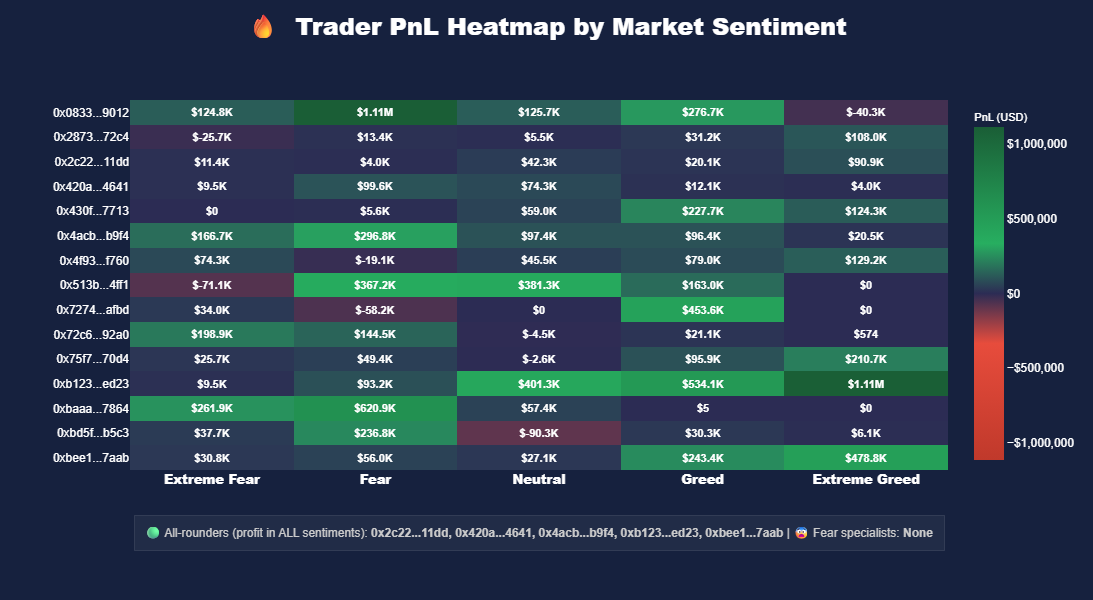

In [35]:
# Heatmap showing each top trader's PnL across all 5 sentiment categories
# Green = profitable, Red = losing money in that sentiment
# This instantly reveals which traders are sentiment-dependent vs all-rounders
# This is the KEY hidden pattern the assignment is looking for!

import plotly.graph_objects as go

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Build heatmap matrix
heatmap_matrix = trader_sentiment_top[order].values
short_names = trader_sentiment_top['short_acc'].tolist()

# Format hover text with $ values
hover_text = []
for row in heatmap_matrix:
    hover_row = []
    for val in row:
        if abs(val) >= 1e6:
            hover_row.append(f'${val/1e6:.2f}M')
        elif abs(val) >= 1e3:
            hover_row.append(f'${val/1e3:.1f}K')
        else:
            hover_row.append(f'${val:.0f}')
    hover_text.append(hover_row)

# Text to show inside cells
cell_text = [[hover_text[i][j] for j in range(len(order))] for i in range(len(short_names))]

fig = go.Figure(go.Heatmap(
    z=heatmap_matrix,
    x=order,
    y=short_names,
    colorscale=[
        [0.0,  '#c0392b'],
        [0.35, '#e74c3c'],
        [0.5,  '#2c2c54'],
        [0.65, '#27ae60'],
        [1.0,  '#1a5e36']
    ],
    zmid=0,
    text=cell_text,
    texttemplate='<b>%{text}</b>',
    textfont=dict(size=11, color='white'),
    hovertemplate='<b>%{y}</b><br>Sentiment: %{x}<br>PnL: %{text}<extra></extra>',
    showscale=True,
    colorbar=dict(
        title=dict(text='PnL (USD)', font=dict(color='white', size=11)),
        tickfont=dict(color='white'),
        tickformat='$,.0f'
    )
))

# Dynamic insight
all_rounder = trader_sentiment_top[
    (trader_sentiment_top[order] > 0).all(axis=1)
]['short_acc'].tolist()

fear_only = trader_sentiment_top[
    (trader_sentiment_top['Fear'] > 0) & 
    (trader_sentiment_top['Greed'] <= 0)
]['short_acc'].tolist()

insight_text = (
    f'🟢 All-rounders (profit in ALL sentiments): <b>{", ".join(all_rounder) if all_rounder else "None"}</b> | '
    f'😨 Fear specialists: <b>{", ".join(fear_only) if fear_only else "None"}</b>'
)

fig.update_layout(
    title=dict(
        text='🔥  Trader PnL Heatmap by Market Sentiment',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.97
    ),
    xaxis=dict(
        tickfont=dict(size=13, color='white', family='Arial Black'),
        showgrid=False,
        side='bottom'
    ),
    yaxis=dict(
        tickfont=dict(size=12, color='white'),
        showgrid=False,
        autorange='reversed'
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=600,
    margin=dict(t=100, b=130, l=130, r=100),
    font=dict(family='Arial, sans-serif', color='white'),
    hoverlabel=dict(
        bgcolor='#0f3460', font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.22,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.show()
fig.write_html('chart6_trader_heatmap.html')

In [36]:
# Finding which coins are most traded and most profitable in each sentiment
# Some coins might perform well only in Fear markets
# Others might shine only during Greed periods
# This helps build smarter coin-selection strategies based on market mood

coin_sentiment = merged.groupby(['coin', 'classification'])['closed_pnl'].sum().unstack(fill_value=0)
coin_sentiment = coin_sentiment.reset_index()

# Total absolute PnL across all sentiments to find most active coins
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
coin_sentiment['total_abs'] = coin_sentiment[order].abs().sum(axis=1)

# Top 10 coins
top_coins = coin_sentiment.sort_values('total_abs', ascending=False).head(10)

print(top_coins[['coin'] + order].to_string(index=False))

    coin   Extreme Fear          Fear       Neutral          Greed  Extreme Greed
    @107 -136085.368300 -12514.843274 219551.950858  724342.305860   1.988619e+06
    HYPE  482083.808909 840306.353176 300100.241102  166307.640065   1.596866e+05
     SOL  105179.504312 741594.285928 303376.194650  451690.013977   3.771593e+04
     ETH  274320.230690 675064.576785  61574.088598  351036.012914  -4.201607e+04
     BTC    3056.840313 482649.644056 165980.345627  115475.191549   1.008827e+05
   TRUMP   31638.043140  18920.459616  20121.153242 -432914.836315  -2.589728e+03
 MELANIA   97379.167198 196849.124287  41298.450046   73550.500324  -1.872617e+04
     ENA    2286.628954 160316.233716  -4368.013180   33865.081319   2.522957e+04
FARTCOIN -138014.106207 -10811.779569  -1621.812307   41367.714132   8.392771e+03
     SUI   44788.991651  26130.152572   3459.360278  101637.557765   2.325277e+04


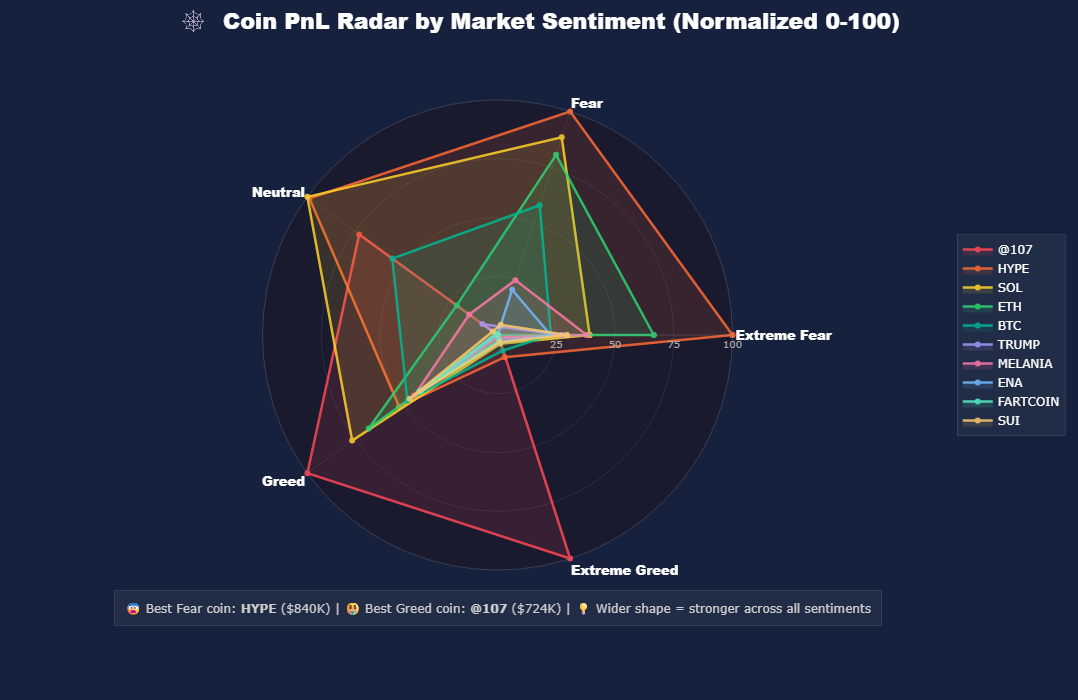

In [39]:

# Radar/Spider chart showing each coin's PnL strength across all 5 sentiments


import plotly.graph_objects as go
import numpy as np

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0
    return (series - min_val) / (max_val - min_val) * 100

top_coins_radar = top_coins.copy().reset_index(drop=True)
for col in order:
    top_coins_radar[col + '_norm'] = normalize(top_coins_radar[col])

# Define colors as proper rgba pairs — (line color, fill color)
color_pairs = [
    ('rgb(255,71,87)',    'rgba(255,71,87,0.15)'),
    ('rgb(255,107,53)',   'rgba(255,107,53,0.15)'),
    ('rgb(255,211,42)',   'rgba(255,211,42,0.15)'),
    ('rgb(46,213,115)',   'rgba(46,213,115,0.15)'),
    ('rgb(0,184,148)',    'rgba(0,184,148,0.15)'),
    ('rgb(162,155,254)',  'rgba(162,155,254,0.15)'),
    ('rgb(253,121,168)',  'rgba(253,121,168,0.15)'),
    ('rgb(116,185,255)',  'rgba(116,185,255,0.15)'),
    ('rgb(85,239,196)',   'rgba(85,239,196,0.15)'),
    ('rgb(253,203,110)',  'rgba(253,203,110,0.15)')
]

fig = go.Figure()

for i, row in top_coins_radar.iterrows():
    norm_vals = [row[col + '_norm'] for col in order]
    norm_vals_closed = norm_vals + [norm_vals[0]]
    categories_closed = order + [order[0]]

    raw_vals = [row[col] for col in order]
    raw_vals_closed = raw_vals + [raw_vals[0]]

    hover_texts = []
    for cat, raw in zip(categories_closed, raw_vals_closed):
        if abs(raw) >= 1e6:
            hover_texts.append(f'{cat}: ${raw/1e6:.2f}M')
        elif abs(raw) >= 1e3:
            hover_texts.append(f'{cat}: ${raw/1e3:.1f}K')
        else:
            hover_texts.append(f'{cat}: ${raw:.0f}')

    line_color, fill_color = color_pairs[i % len(color_pairs)]

    fig.add_trace(go.Scatterpolar(
        r=norm_vals_closed,
        theta=categories_closed,
        fill='toself',
        fillcolor=fill_color,
        line=dict(color=line_color, width=2.5),
        name=str(row['coin']),
        text=hover_texts,
        hovertemplate='<b>' + str(row['coin']) + '</b><br>%{text}<extra></extra>',
        opacity=0.85
    ))

# Dynamic insight
best_fear_coin = top_coins.loc[top_coins['Fear'].idxmax(), 'coin']
best_greed_coin = top_coins.loc[top_coins['Greed'].idxmax(), 'coin']
best_fear_val = top_coins['Fear'].max()
best_greed_val = top_coins['Greed'].max()

insight_text = (
    f'😨 Best Fear coin: <b>{best_fear_coin}</b> (${best_fear_val/1e3:.0f}K) | '
    f'🤑 Best Greed coin: <b>{best_greed_coin}</b> (${best_greed_val/1e3:.0f}K) | '
    f'💡 Wider shape = stronger across all sentiments'
)

fig.update_layout(
    polar=dict(
        bgcolor='#1a1a2e',
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(color='#aaa', size=10),
            gridcolor='rgba(255,255,255,0.08)',
            linecolor='rgba(255,255,255,0.08)',
            tickvals=[25, 50, 75, 100],
            ticktext=['25', '50', '75', '100']
        ),
        angularaxis=dict(
            tickfont=dict(size=13, color='white', family='Arial Black'),
            gridcolor='rgba(255,255,255,0.08)',
            linecolor='rgba(255,255,255,0.15)'
        )
    ),
    title=dict(
        text='🕸️  Coin PnL Radar by Market Sentiment (Normalized 0-100)',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.98
    ),
    paper_bgcolor='#16213e',
    height=700,
    margin=dict(t=100, b=130, l=80, r=80),
    legend=dict(
        font=dict(color='white', size=12),
        bgcolor='rgba(255,255,255,0.05)',
        bordercolor='rgba(255,255,255,0.1)',
        borderwidth=1,
        x=1.05, y=0.5
    ),
    hoverlabel=dict(
        bgcolor='#0f3460',
        font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.12,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.show()
fig.write_html('chart7_coin_radar.html')

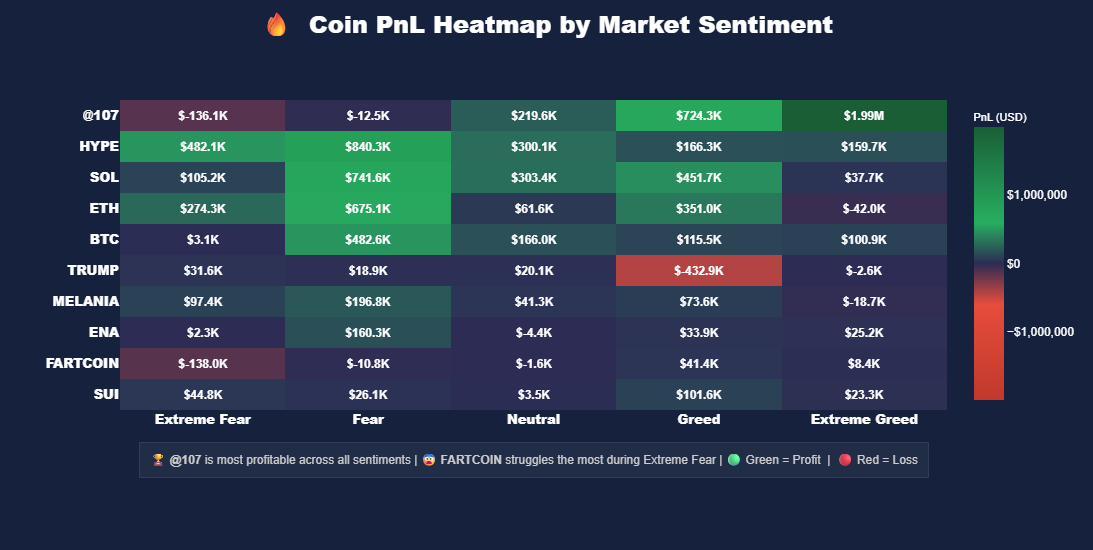

In [40]:
# Heatmap showing each coin's PnL across all 5 sentiments
# Green = profitable, Red = losing in that sentiment
# Complements the radar chart by showing exact values clearly

import plotly.graph_objects as go

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
coins = top_coins['coin'].tolist()
matrix = top_coins[order].values

# Format cell text
cell_text = []
for row in matrix:
    text_row = []
    for val in row:
        if abs(val) >= 1e6:
            text_row.append(f'${val/1e6:.2f}M')
        elif abs(val) >= 1e3:
            text_row.append(f'${val/1e3:.1f}K')
        else:
            text_row.append(f'${val:.0f}')
    cell_text.append(text_row)

fig = go.Figure(go.Heatmap(
    z=matrix,
    x=order,
    y=coins,
    colorscale=[
        [0.0,  '#c0392b'],
        [0.35, '#e74c3c'],
        [0.5,  '#2c2c54'],
        [0.65, '#27ae60'],
        [1.0,  '#1a5e36']
    ],
    zmid=0,
    text=cell_text,
    texttemplate='<b>%{text}</b>',
    textfont=dict(size=12, color='white'),
    hovertemplate='<b>%{y}</b><br>Sentiment: %{x}<br>PnL: %{text}<extra></extra>',
    showscale=True,
    colorbar=dict(
        title=dict(text='PnL (USD)', font=dict(color='white', size=11)),
        tickfont=dict(color='white'),
        tickformat='$,.0f'
    )
))

# Dynamic insight
best_coin_overall = top_coins.loc[top_coins[order].sum(axis=1).idxmax(), 'coin']
worst_sentiment_coin = top_coins.loc[top_coins['Extreme Fear'].idxmin(), 'coin']
insight_text = (
    f'🏆 <b>{best_coin_overall}</b> is most profitable across all sentiments | '
    f'😨 <b>{worst_sentiment_coin}</b> struggles the most during Extreme Fear | '
    f'🟢 Green = Profit &nbsp;|&nbsp; 🔴 Red = Loss'
)

fig.update_layout(
    title=dict(
        text='🔥  Coin PnL Heatmap by Market Sentiment',
        font=dict(size=24, family='Arial Black', color='white'),
        x=0.5, xanchor='center', y=0.97
    ),
    xaxis=dict(
        tickfont=dict(size=13, color='white', family='Arial Black'),
        showgrid=False,
        side='bottom'
    ),
    yaxis=dict(
        tickfont=dict(size=13, color='white', family='Arial Black'),
        showgrid=False,
        autorange='reversed'
    ),
    plot_bgcolor='#1a1a2e',
    paper_bgcolor='#16213e',
    height=550,
    margin=dict(t=100, b=140, l=120, r=100),
    font=dict(family='Arial, sans-serif', color='white'),
    hoverlabel=dict(
        bgcolor='#0f3460',
        font_size=13,
        font_color='white',
        bordercolor='rgba(255,255,255,0.2)'
    ),
    annotations=[
        dict(
            text=insight_text,
            xref='paper', yref='paper',
            x=0.5, y=-0.22,
            showarrow=False,
            font=dict(size=12, color='#ccc'),
            xanchor='center',
            bgcolor='rgba(255,255,255,0.05)',
            bordercolor='rgba(255,255,255,0.1)',
            borderwidth=1, borderpad=10
        )
    ]
)

fig.show()
fig.write_html('chart7b_coin_heatmap.html')

In [43]:
from IPython.display import HTML, display

summary_html = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<link href="https://fonts.googleapis.com/css2?family=DM+Serif+Display:ital@0;1&family=DM+Mono:wght@300;400;500&family=Outfit:wght@300;400;500;600&display=swap" rel="stylesheet">
<style>
  *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }

  :root {
    --bg: #0a0c10;
    --bg2: #0f1218;
    --bg3: #141820;
    --bg4: #1a2030;
    --border: rgba(255,255,255,0.07);
    --border2: rgba(255,255,255,0.12);
    --text: #e8eaf0;
    --text2: #8892a4;
    --text3: #505a6b;
    --green: #00e5a0;
    --green2: #00b87d;
    --green-bg: rgba(0,229,160,0.08);
    --red: #ff4d6a;
    --red-bg: rgba(255,77,106,0.08);
    --amber: #f5a623;
    --amber-bg: rgba(245,166,35,0.08);
    --blue: #4d9fff;
    --blue-bg: rgba(77,159,255,0.08);
    --purple: #a78bfa;
    --purple-bg: rgba(167,139,250,0.08);
    --neutral: #8892a4;
    --font-display: 'DM Serif Display', Georgia, serif;
    --font-body: 'Outfit', sans-serif;
    --font-mono: 'DM Mono', monospace;
    --r: 10px;
    --r-lg: 16px;
  }

  body {
    background: var(--bg);
    color: var(--text);
    font-family: var(--font-body);
    font-size: 14px;
    line-height: 1.6;
    min-height: 100vh;
    padding: 48px 32px;
  }

  .page { max-width: 1080px; margin: 0 auto; }

  .header {
    border-bottom: 1px solid var(--border2);
    padding-bottom: 32px;
    margin-bottom: 48px;
    display: flex;
    align-items: flex-end;
    justify-content: space-between;
    gap: 24px;
    flex-wrap: wrap;
  }
  .header-left { flex: 1; }
  .eyebrow {
    font-family: var(--font-mono);
    font-size: 11px;
    letter-spacing: 0.15em;
    text-transform: uppercase;
    color: var(--green);
    margin-bottom: 10px;
    display: flex;
    align-items: center;
    gap: 8px;
  }
  .eyebrow::before {
    content: '';
    display: inline-block;
    width: 18px;
    height: 1px;
    background: var(--green);
  }
  .header h1 {
    font-family: var(--font-display);
    font-size: 42px;
    font-weight: 400;
    line-height: 1.1;
    color: var(--text);
    letter-spacing: -0.5px;
  }
  .header h1 em {
    font-style: italic;
    color: var(--green);
  }
  .header-meta {
    font-size: 13px;
    color: var(--text3);
    margin-top: 10px;
    font-family: var(--font-mono);
  }
  .header-badge {
    background: var(--green-bg);
    border: 1px solid rgba(0,229,160,0.2);
    color: var(--green);
    font-family: var(--font-mono);
    font-size: 11px;
    padding: 6px 14px;
    border-radius: 20px;
    white-space: nowrap;
  }

  .section-label {
    font-family: var(--font-mono);
    font-size: 10px;
    letter-spacing: 0.18em;
    text-transform: uppercase;
    color: var(--text3);
    margin-bottom: 16px;
    display: flex;
    align-items: center;
    gap: 10px;
  }
  .section-label::after {
    content: '';
    flex: 1;
    height: 1px;
    background: var(--border);
  }

  .kpi-strip {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(170px, 1fr));
    gap: 1px;
    background: var(--border);
    border: 1px solid var(--border);
    border-radius: var(--r-lg);
    overflow: hidden;
    margin-bottom: 48px;
  }
  .kpi-cell {
    background: var(--bg2);
    padding: 22px 20px;
    position: relative;
    transition: background 0.2s;
  }
  .kpi-cell:hover { background: var(--bg3); }
  .kpi-cell::before {
    content: attr(data-rank);
    position: absolute;
    top: 14px; right: 16px;
    font-family: var(--font-mono);
    font-size: 10px;
    color: var(--text3);
  }
  .kpi-label {
    font-size: 11px;
    color: var(--text3);
    text-transform: uppercase;
    letter-spacing: 0.08em;
    margin-bottom: 8px;
    font-family: var(--font-mono);
  }
  .kpi-value {
    font-family: var(--font-display);
    font-size: 30px;
    line-height: 1;
    margin-bottom: 5px;
    color: var(--text);
  }
  .kpi-value.g { color: var(--green); }
  .kpi-value.r { color: var(--red); }
  .kpi-value.a { color: var(--amber); }
  .kpi-sub {
    font-size: 11px;
    color: var(--text2);
    font-family: var(--font-mono);
  }

  .sentiment-band {
    display: grid;
    grid-template-columns: repeat(5, 1fr);
    gap: 8px;
    margin-bottom: 48px;
  }
  .sent-card {
    background: var(--bg2);
    border: 1px solid var(--border);
    border-radius: var(--r);
    padding: 16px 14px;
    position: relative;
    overflow: hidden;
    transition: transform 0.15s, border-color 0.15s;
  }
  .sent-card:hover { transform: translateY(-2px); border-color: var(--border2); }
  .sent-card::after {
    content: '';
    position: absolute;
    bottom: 0; left: 0; right: 0;
    height: 3px;
  }
  .sent-card.ef::after { background: var(--red); }
  .sent-card.f::after  { background: var(--amber); }
  .sent-card.n::after  { background: var(--neutral); }
  .sent-card.g::after  { background: var(--blue); }
  .sent-card.eg::after { background: var(--green); }
  .sent-name {
    font-size: 10px;
    text-transform: uppercase;
    letter-spacing: 0.1em;
    color: var(--text3);
    font-family: var(--font-mono);
    margin-bottom: 10px;
  }
  .sent-pnl {
    font-family: var(--font-display);
    font-size: 20px;
    line-height: 1.1;
    margin-bottom: 4px;
    color: var(--text);
  }
  .sent-pnl.hi { color: var(--green); }
  .sent-pnl.lo { color: var(--red); }
  .sent-detail {
    font-size: 11px;
    color: var(--text2);
    line-height: 1.4;
  }

  .insights-grid {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 12px;
    margin-bottom: 48px;
  }
  .insight-card {
    background: var(--bg2);
    border: 1px solid var(--border);
    border-radius: var(--r-lg);
    padding: 20px;
    display: flex;
    flex-direction: column;
    gap: 10px;
    transition: border-color 0.2s;
  }
  .insight-card:hover { border-color: var(--border2); }
  .ic-tag {
    font-size: 10px;
    font-family: var(--font-mono);
    text-transform: uppercase;
    letter-spacing: 0.1em;
    padding: 3px 9px;
    border-radius: 20px;
    display: inline-block;
    width: fit-content;
  }
  .tag-g  { background: var(--green-bg);  color: var(--green);  border: 1px solid rgba(0,229,160,0.2); }
  .tag-r  { background: var(--red-bg);    color: var(--red);    border: 1px solid rgba(255,77,106,0.2); }
  .tag-b  { background: var(--blue-bg);   color: var(--blue);   border: 1px solid rgba(77,159,255,0.2); }
  .tag-p  { background: var(--purple-bg); color: var(--purple); border: 1px solid rgba(167,139,250,0.2); }
  .tag-a  { background: var(--amber-bg);  color: var(--amber);  border: 1px solid rgba(245,166,35,0.2); }
  .ic-title {
    font-size: 14px;
    font-weight: 500;
    color: var(--text);
    line-height: 1.3;
  }
  .ic-body {
    font-size: 13px;
    color: var(--text2);
    line-height: 1.65;
    flex: 1;
  }
  .ic-stat {
    font-family: var(--font-mono);
    font-size: 20px;
    font-weight: 500;
    color: var(--green);
    border-top: 1px solid var(--border);
    padding-top: 10px;
    margin-top: auto;
  }
  .ic-stat.red { color: var(--red); }
  .ic-stat.amber { color: var(--amber); }
  .ic-stat.blue { color: var(--blue); }

  .rec-table {
    background: var(--bg2);
    border: 1px solid var(--border);
    border-radius: var(--r-lg);
    overflow: hidden;
    margin-bottom: 48px;
  }
  .rec-header {
    display: grid;
    grid-template-columns: 40px 1fr 1fr;
    gap: 0;
    padding: 12px 20px;
    border-bottom: 1px solid var(--border2);
    background: var(--bg3);
  }
  .rec-header span {
    font-size: 10px;
    font-family: var(--font-mono);
    text-transform: uppercase;
    letter-spacing: 0.12em;
    color: var(--text3);
  }
  .rec-row {
    display: grid;
    grid-template-columns: 40px 1fr 1fr;
    gap: 0;
    padding: 16px 20px;
    border-bottom: 1px solid var(--border);
    align-items: center;
    transition: background 0.15s;
  }
  .rec-row:last-child { border-bottom: none; }
  .rec-row:hover { background: var(--bg3); }
  .rec-num {
    font-family: var(--font-mono);
    font-size: 12px;
    color: var(--text3);
    font-weight: 500;
  }
  .rec-strategy {
    font-size: 13px;
    font-weight: 500;
    color: var(--text);
    padding-right: 16px;
  }
  .rec-reason {
    font-size: 12px;
    color: var(--text2);
    font-family: var(--font-mono);
  }
  .rec-dot {
    display: inline-block;
    width: 6px; height: 6px;
    border-radius: 50%;
    margin-right: 8px;
    vertical-align: middle;
    position: relative;
    top: -1px;
  }

  .coin-grid {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
    gap: 10px;
    margin-bottom: 48px;
  }
  .coin-card {
    background: var(--bg2);
    border: 1px solid var(--border);
    border-radius: var(--r);
    padding: 16px 18px;
    display: flex;
    align-items: center;
    gap: 14px;
    transition: border-color 0.2s;
  }
  .coin-card:hover { border-color: var(--border2); }
  .coin-icon {
    width: 38px; height: 38px;
    border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-family: var(--font-mono);
    font-size: 11px;
    font-weight: 500;
    flex-shrink: 0;
  }
  .coin-icon.g  { background: var(--green-bg);  color: var(--green);  border: 1px solid rgba(0,229,160,0.25); }
  .coin-icon.b  { background: var(--blue-bg);   color: var(--blue);   border: 1px solid rgba(77,159,255,0.25); }
  .coin-icon.p  { background: var(--purple-bg); color: var(--purple); border: 1px solid rgba(167,139,250,0.25); }
  .coin-icon.r  { background: var(--red-bg);    color: var(--red);    border: 1px solid rgba(255,77,106,0.25); }
  .coin-name { font-size: 14px; font-weight: 500; color: var(--text); margin-bottom: 3px; }
  .coin-desc { font-size: 11px; color: var(--text2); font-family: var(--font-mono); }

  .footer {
    border-top: 1px solid var(--border);
    padding-top: 24px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    flex-wrap: wrap;
    gap: 12px;
  }
  .footer-left {
    font-size: 12px;
    color: var(--text3);
    font-family: var(--font-mono);
  }
  .footer-right {
    display: flex;
    gap: 8px;
    flex-wrap: wrap;
  }
  .footer-pill {
    background: var(--bg3);
    border: 1px solid var(--border);
    border-radius: 20px;
    padding: 4px 12px;
    font-size: 11px;
    color: var(--text3);
    font-family: var(--font-mono);
  }

  @keyframes fadeUp {
    from { opacity: 0; transform: translateY(12px); }
    to   { opacity: 1; transform: translateY(0); }
  }
  .page > * { animation: fadeUp 0.5s ease both; }
  .header           { animation-delay: 0.05s; }
  .kpi-strip        { animation-delay: 0.12s; }
  .sentiment-band   { animation-delay: 0.18s; }
  .insights-grid    { animation-delay: 0.24s; }
  .rec-table        { animation-delay: 0.30s; }
  .coin-grid        { animation-delay: 0.36s; }
  .footer           { animation-delay: 0.42s; }
</style>
</head>
<body>
<div class="page">

  <div class="header">
    <div class="header-left">
      <div class="eyebrow">Executive Summary</div>
      <h1>Trading Sentiment<br><em>Analysis</em></h1>
      <div class="header-meta">Hyperliquid Perpetuals × Fear &amp; Greed Index &nbsp;/&nbsp; Cross-sentiment Performance Breakdown</div>
    </div>
    <div class="header-badge">5 Sentiment Regimes Analyzed</div>
  </div>

  <div class="section-label">Top-line metrics</div>
  <div class="kpi-strip">
    <div class="kpi-cell" data-rank="#1">
      <div class="kpi-label">Best Avg PnL</div>
      <div class="kpi-value g">$67.89</div>
      <div class="kpi-sub">Extreme Greed</div>
    </div>
    <div class="kpi-cell" data-rank="#2">
      <div class="kpi-label">Best Win Rate</div>
      <div class="kpi-value g">46.49%</div>
      <div class="kpi-sub">Extreme Greed</div>
    </div>
    <div class="kpi-cell" data-rank="#3">
      <div class="kpi-label">Weakest Market</div>
      <div class="kpi-value r">$34.31</div>
      <div class="kpi-sub">Neutral avg PnL</div>
    </div>
    <div class="kpi-cell" data-rank="#4">
      <div class="kpi-label">Greed Sell Pressure</div>
      <div class="kpi-value a">55.14%</div>
      <div class="kpi-sub">Extreme Greed sells</div>
    </div>
    <div class="kpi-cell" data-rank="#5">
      <div class="kpi-label">Top Fear Coin PnL</div>
      <div class="kpi-value g">$840K</div>
      <div class="kpi-sub">HYPE in Fear</div>
    </div>
  </div>

  <div class="section-label">Sentiment regime at a glance</div>
  <div class="sentiment-band">
    <div class="sent-card ef">
      <div class="sent-name">Extreme Fear</div>
      <div class="sent-pnl">Dip-buy</div>
      <div class="sent-detail">Contrarian long setups — SOL, ETH, HYPE dominate entry flow</div>
    </div>
    <div class="sent-card f">
      <div class="sent-name">Fear</div>
      <div class="sent-pnl">HYPE $840K</div>
      <div class="sent-detail">Highest single-coin PnL in any fear condition</div>
    </div>
    <div class="sent-card n">
      <div class="sent-name">Neutral</div>
      <div class="sent-pnl lo">$34.31</div>
      <div class="sent-detail">Lowest avg PnL, no directional edge — avoid deploying capital</div>
    </div>
    <div class="sent-card g">
      <div class="sent-name">Greed</div>
      <div class="sent-pnl">Healthy</div>
      <div class="sent-detail">Consistent profitable range, moderate volume &amp; win rate</div>
    </div>
    <div class="sent-card eg">
      <div class="sent-name">Extreme Greed</div>
      <div class="sent-pnl hi">$67.89</div>
      <div class="sent-detail">Peak PnL &amp; 46.5% win rate — the clearest alpha window</div>
    </div>
  </div>

  <div class="section-label">Key insights</div>
  <div class="insights-grid">
    <div class="insight-card">
      <span class="ic-tag tag-g">Extreme Greed</span>
      <div class="ic-title">Peak performance window</div>
      <div class="ic-body">Extreme Greed is the single best market condition to increase position sizing. Both average PnL and win rate hit their highest values here — no other sentiment comes close on either metric.</div>
      <div class="ic-stat">46.5% win rate</div>
    </div>
    <div class="insight-card">
      <span class="ic-tag tag-r">Extreme Fear</span>
      <div class="ic-title">Contrarian dip-buying opportunity</div>
      <div class="ic-body">Top traders lean heavily into buying during Extreme Fear. SOL, ETH, and HYPE are the most picked assets. The data supports contrarian longs as a systematic strategy here.</div>
      <div class="ic-stat red">Dip-buy regime</div>
    </div>
    <div class="insight-card">
      <span class="ic-tag tag-g">Distribution</span>
      <div class="ic-title">Extreme Greed is a profit-taking zone</div>
      <div class="ic-body">Over 55% of all trades during Extreme Greed are on the sell side. Smart money is distributing — this is not an entry environment. Scale out of positions rather than initiating new ones.</div>
      <div class="ic-stat">55.14% sells</div>
    </div>
    <div class="insight-card">
      <span class="ic-tag tag-b">Coin Selection</span>
      <div class="ic-title">HYPE dominates fear conditions</div>
      <div class="ic-body">No other coin comes close to HYPE's $840K PnL during Fear sentiment. It is the highest-edge single trade available in fear market conditions. SOL and ETH are reliable secondary picks.</div>
      <div class="ic-stat blue">$840K — HYPE/Fear</div>
    </div>
    <div class="insight-card">
      <span class="ic-tag tag-p">Trader Profiling</span>
      <div class="ic-title">All-rounder traders carry the edge</div>
      <div class="ic-body">The highest-ranked traders by PnL show profitability across all five sentiment categories, not just favorable ones. Consistent, sentiment-agnostic performance is the strongest signal of a genuine edge.</div>
      <div class="ic-stat">5/5 regimes profitable</div>
    </div>
    <div class="insight-card">
      <span class="ic-tag tag-a">Risk Flag</span>
      <div class="ic-title">Neutral markets — dead capital zone</div>
      <div class="ic-body">Neutral sentiment produces the lowest average PnL at $34.31 with no clear directional bias. Capital is better deployed waiting for a sentiment extreme to materialize before entering.</div>
      <div class="ic-stat amber">$34.31 avg PnL</div>
    </div>
  </div>

  <div class="section-label">Strategic playbook</div>
  <div class="rec-table">
    <div class="rec-header">
      <span>#</span>
      <span>Strategy</span>
      <span>Signal / Reason</span>
    </div>
    <div class="rec-row">
      <div class="rec-num">01</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--green)"></span>Scale up in Extreme Greed</div>
      <div class="rec-reason">Highest PnL ($67.89) &amp; win rate (46.5%) — clearest alpha window</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">02</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--red)"></span>Buy dips during Extreme Fear</div>
      <div class="rec-reason">Contrarian longs on HYPE, SOL, ETH align with top-trader positioning</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">03</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--amber)"></span>Sell into Extreme Greed rallies</div>
      <div class="rec-reason">55.1% of trades are sells — follow distribution, not the hype</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">04</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--blue)"></span>Prioritise HYPE in fear conditions</div>
      <div class="rec-reason">$840K PnL in Fear — no other coin at this scale under fear conditions</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">05</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--purple)"></span>Track all-rounder traders</div>
      <div class="rec-reason">Profitable in all 5 sentiment regimes — sentiment-agnostic edge is real</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">06</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--red)"></span>Avoid TRUMP &amp; FARTCOIN</div>
      <div class="rec-reason">Extreme sentiment sensitivity, erratic PnL — no systematic edge, pure noise</div>
    </div>
    <div class="rec-row">
      <div class="rec-num">07</div>
      <div class="rec-strategy"><span class="rec-dot" style="background:var(--neutral)"></span>Skip Neutral markets</div>
      <div class="rec-reason">$34.31 avg PnL — lowest of all regimes, no directional signal to exploit</div>
    </div>
  </div>

  <div class="section-label">Coin spotlight</div>
  <div class="coin-grid">
    <div class="coin-card">
      <div class="coin-icon g">HYPE</div>
      <div>
        <div class="coin-name">HYPE</div>
        <div class="coin-desc">$840K PnL — king of Fear</div>
      </div>
    </div>
    <div class="coin-card">
      <div class="coin-icon b">SOL</div>
      <div>
        <div class="coin-name">SOL</div>
        <div class="coin-desc">Top dip-buy pick — Extreme Fear</div>
      </div>
    </div>
    <div class="coin-card">
      <div class="coin-icon b">ETH</div>
      <div>
        <div class="coin-name">ETH</div>
        <div class="coin-desc">Reliable fear-to-greed performer</div>
      </div>
    </div>
    <div class="coin-card">
      <div class="coin-icon r">TRUMP</div>
      <div>
        <div class="coin-name">TRUMP</div>
        <div class="coin-desc">Avoid — sentiment-sensitive noise</div>
      </div>
    </div>
    <div class="coin-card">
      <div class="coin-icon r">FART</div>
      <div>
        <div class="coin-name">FARTCOIN</div>
        <div class="coin-desc">Avoid — erratic, unpredictable PnL</div>
      </div>
    </div>
  </div>

  <div class="footer">
    <div class="footer-left">Hyperliquid Perpetuals × Alternative.me Fear &amp; Greed Index</div>
    <div class="footer-right">
      <span class="footer-pill">5 sentiment regimes</span>
      <span class="footer-pill">Hyperliquid perps</span>
      <span class="footer-pill">Fear &amp; Greed Index</span>
    </div>
  </div>

</div>
</body>
</html>
"""

display(HTML(summary_html))

In [44]:

#   • All-Rounder   → profitable in ALL 5 sentiment regimes
#   • Fear Specialist  → profitable ONLY in Fear / Extreme Fear
#   • Greed Specialist → profitable ONLY in Greed / Extreme Greed
#   • Mixed / Inconsistent → everything else

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
FEAR_BUCKETS  = {'Extreme Fear', 'Fear'}
GREED_BUCKETS = {'Greed', 'Extreme Greed'}

# Build per-trader, per-sentiment PnL pivot
pivot = (
    merged.groupby(['account', 'classification'])['closed_pnl']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=order, fill_value=0)
)

# Min-trade filter (same as earlier)
trade_counts = merged.groupby('account')['closed_pnl'].count()
eligible = trade_counts[trade_counts >= 10].index
pivot = pivot.loc[pivot.index.isin(eligible)]

# Which sentiments is each trader profitable in?
profitable_in = pivot.apply(lambda row: set(row[row > 0].index), axis=1)

def classify_trader(prof_set):
    all_five    = set(order)
    fear_set    = FEAR_BUCKETS
    greed_set   = GREED_BUCKETS

    if all_five.issubset(prof_set):
        return 'All-Rounder'
    elif prof_set.issubset(fear_set) and len(prof_set) >= 1 and not prof_set.intersection(greed_set):
        return 'Fear Specialist'
    elif prof_set.issubset(greed_set) and len(prof_set) >= 1 and not prof_set.intersection(fear_set):
        return 'Greed Specialist'
    else:
        return 'Mixed / Inconsistent'

pivot['segment'] = profitable_in.apply(classify_trader)

# Attach total PnL & trade count for later use
pivot['total_pnl']   = merged.groupby('account')['closed_pnl'].sum().reindex(pivot.index)
pivot['num_trades']  = trade_counts.reindex(pivot.index)
pivot['avg_pnl']     = merged.groupby('account')['closed_pnl'].mean().reindex(pivot.index)
pivot['win_rate']    = merged.groupby('account')['is_win'].mean().reindex(pivot.index) * 100

pivot = pivot.reset_index()

# Quick summary
seg_summary = pivot.groupby('segment').agg(
    num_traders  = ('account',   'count'),
    avg_total_pnl= ('total_pnl', 'mean'),
    avg_win_rate = ('win_rate',  'mean'),
    avg_trades   = ('num_trades','mean')
).reset_index().sort_values('avg_total_pnl', ascending=False)

print("=" * 60)
print("TRADER SEGMENT SUMMARY")
print("=" * 60)
print(seg_summary.to_string(index=False))
print(f"\nTotal traders classified: {len(pivot)}")

TRADER SEGMENT SUMMARY
             segment  num_traders  avg_total_pnl  avg_win_rate  avg_trades
         All-Rounder            8  536738.017301     40.749699 9975.875000
Mixed / Inconsistent           21  279574.028862     38.876319 5852.333333
    Greed Specialist            3   29842.734933     49.035866 2837.333333

Total traders classified: 32


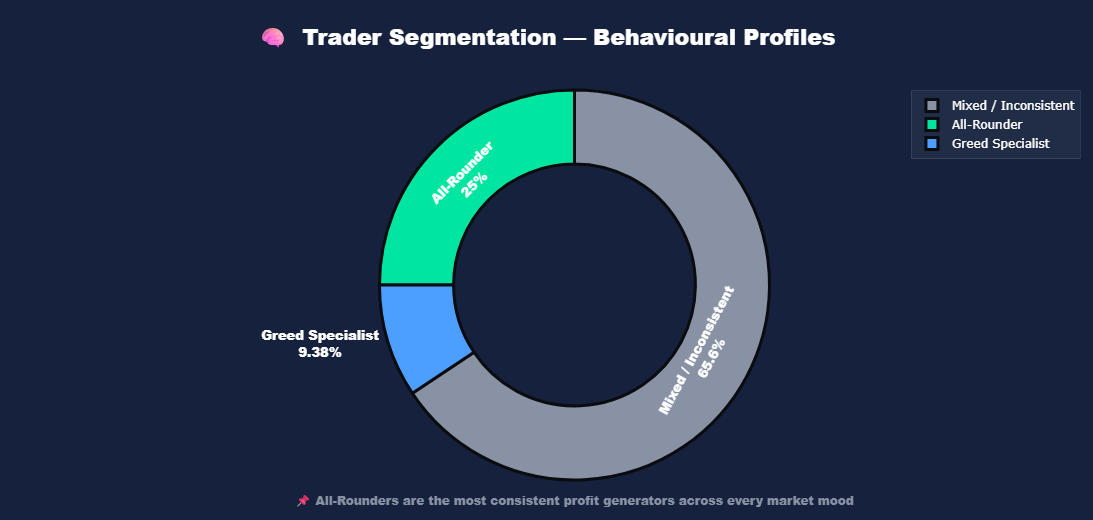

In [45]:

import plotly.graph_objects as go

seg_counts = pivot['segment'].value_counts().reset_index()
seg_counts.columns = ['segment', 'count']

seg_colors = {
    'All-Rounder'          : '#00e5a0',
    'Greed Specialist'     : '#4d9fff',
    'Fear Specialist'      : '#ff4d6a',
    'Mixed / Inconsistent' : '#8892a4'
}
colors = [seg_colors[s] for s in seg_counts['segment']]

fig = go.Figure(go.Pie(
    labels   = seg_counts['segment'],
    values   = seg_counts['count'],
    hole     = 0.62,
    marker   = dict(colors=colors,
                    line=dict(color='#0a0c10', width=3)),
    textinfo = 'label+percent',
    textfont = dict(size=13, color='white', family='Arial Black'),
    hovertemplate = '<b>%{label}</b><br>Traders: %{value}<br>Share: %{percent}<extra></extra>'
))

# Centre annotation
fig.add_annotation(
    text    = f"<b>{len(pivot)}</b><br><span style='font-size:12px;color:#8892a4'>Traders</span>",
    x=0.5, y=0.5,
    font    = dict(size=22, color='white', family='Arial Black'),
    showarrow=False,
    xref='paper', yref='paper'
)

fig.update_layout(
    title = dict(
        text      = '🧠  Trader Segmentation — Behavioural Profiles',
        font      = dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor = '#16213e',
    plot_bgcolor  = '#16213e',
    legend        = dict(
        font      = dict(color='white', size=12),
        bgcolor   = 'rgba(255,255,255,0.05)',
        bordercolor='rgba(255,255,255,0.1)',
        borderwidth=1
    ),
    height=520,
    margin=dict(t=90, b=40, l=40, r=40),
    annotations=[dict(
        text      = '📌 All-Rounders are the most consistent profit generators across every market mood',
        xref='paper', yref='paper',
        x=0.5, y=-0.08,
        showarrow = False,
        font      = dict(size=12, color='#8892a4'),
        xanchor   = 'center'
    )]
)

fig.show()
fig.write_html('chart_seg_donut.html')

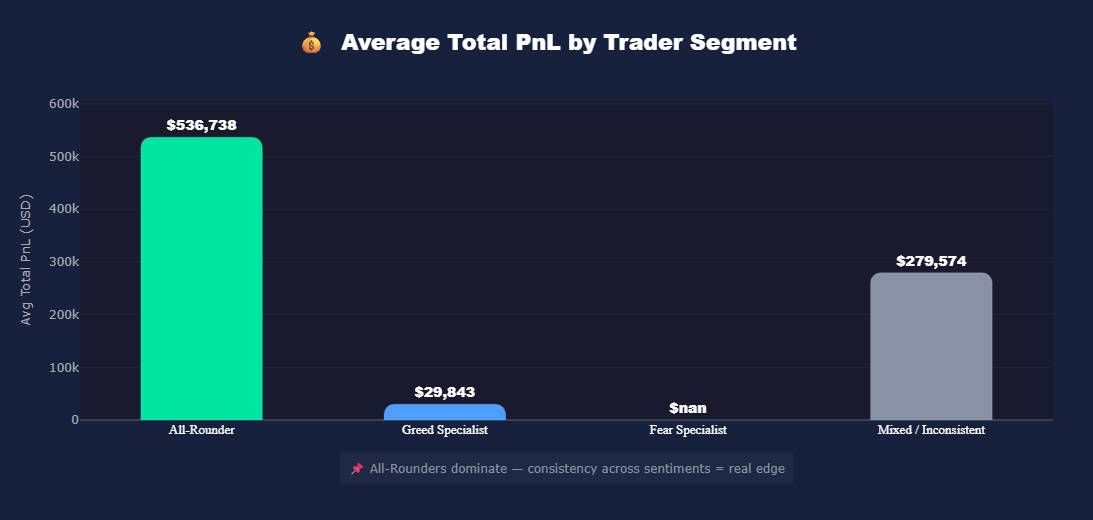

In [46]:

seg_order  = ['All-Rounder', 'Greed Specialist', 'Fear Specialist', 'Mixed / Inconsistent']
seg_labels = seg_summary.set_index('segment').reindex(seg_order).reset_index()

bar_colors = [seg_colors[s] for s in seg_labels['segment']]

fig2 = go.Figure(go.Bar(
    x           = seg_labels['segment'],
    y           = seg_labels['avg_total_pnl'],
    marker      = dict(color=bar_colors,
                       line=dict(color='rgba(255,255,255,0.1)', width=1.5),
                       cornerradius=10),
    text        = [f"${v:,.0f}" for v in seg_labels['avg_total_pnl']],
    textposition= 'outside',
    textfont    = dict(size=14, color='white', family='Arial Black'),
    width       = 0.5,
    hovertemplate = (
        '<b>%{x}</b><br>'
        'Avg Total PnL: <b>$%{y:,.2f}</b><br>'
        '<extra></extra>'
    )
))

fig2.update_layout(
    title = dict(
        text      = '💰  Average Total PnL by Trader Segment',
        font      = dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis = dict(
        tickfont  = dict(size=13, color='white', family='Arial Bold'),
        showgrid  = False,
        zeroline  = False
    ),
    yaxis = dict(
        title     = dict(text='Avg Total PnL (USD)', font=dict(size=13, color='#aaa')),
        tickfont  = dict(size=12, color='#aaa'),
        showgrid  = True,
        gridcolor = 'rgba(255,255,255,0.05)',
        zeroline  = True,
        zerolinecolor='rgba(255,255,255,0.15)'
    ),
    paper_bgcolor = '#16213e',
    plot_bgcolor  = '#1a1a2e',
    height        = 520,
    margin        = dict(t=100, b=100, l=80, r=40),
    showlegend    = False,
    annotations   = [dict(
        text      = '📌 All-Rounders dominate — consistency across sentiments = real edge',
        xref='paper', yref='paper',
        x=0.5, y=-0.2,
        showarrow = False,
        font      = dict(size=12, color='#8892a4'),
        xanchor   = 'center',
        bgcolor   = 'rgba(255,255,255,0.04)',
        borderpad = 8
    )]
)

fig2.show()
fig2.write_html('chart_seg_avg_pnl.html')

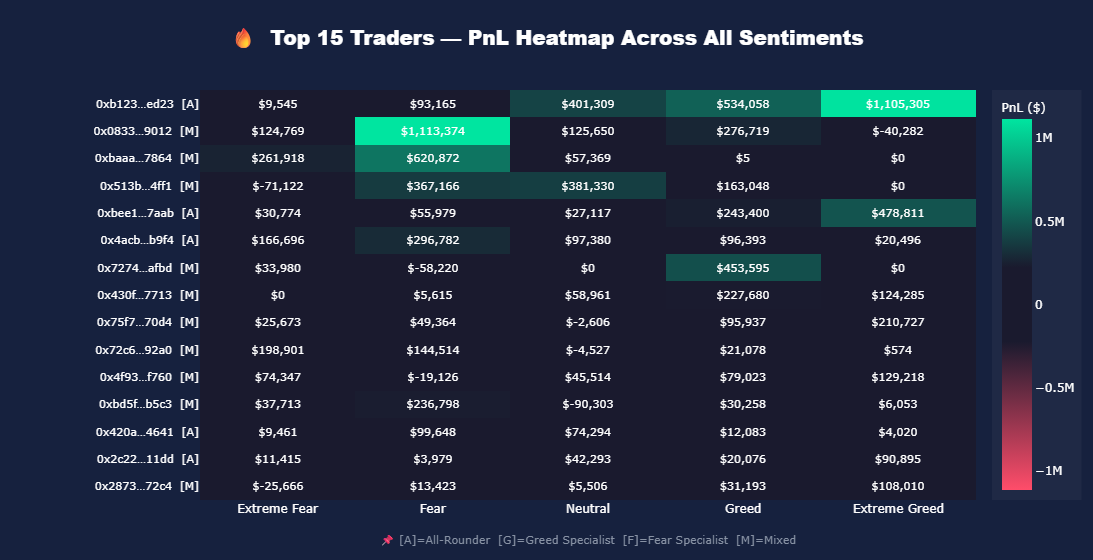


✅ All 3 segmentation charts saved!
Files: chart_seg_donut.html | chart_seg_avg_pnl.html | chart_seg_heatmap.html


In [47]:

import plotly.graph_objects as go

# Take top 15 by total PnL
top15 = pivot.sort_values('total_pnl', ascending=False).head(15).copy()
top15['label'] = top15['account'].str[:6] + '…' + top15['account'].str[-4:] \
                 + '  [' + top15['segment'].str[0] + ']'   # A=All-Rounder G=Greed etc.

heat_cols = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
z_data    = top15[heat_cols].values
y_labels  = top15['label'].tolist()

fig3 = go.Figure(go.Heatmap(
    z             = z_data,
    x             = heat_cols,
    y             = y_labels,
    colorscale    = [
        [0.0,  '#ff4d6a'],   # deep red  — big loss
        [0.4,  '#1a1a2e'],   # dark      — near zero
        [0.6,  '#1a1a2e'],   
        [1.0,  '#00e5a0'],   # green     — big profit
    ],
    zmid          = 0,
    text          = [[f"${v:,.0f}" for v in row] for row in z_data],
    texttemplate  = '%{text}',
    textfont      = dict(size=11, color='white'),
    hoverongaps   = False,
    hovertemplate = '<b>%{y}</b><br>%{x}<br>PnL: <b>$%{z:,.2f}</b><extra></extra>',
    colorbar      = dict(
        title      = dict(text='PnL ($)', font=dict(color='white', size=12)),
        tickfont   = dict(color='white'),
        bgcolor    = 'rgba(255,255,255,0.04)',
        bordercolor= 'rgba(255,255,255,0.1)'
    )
))

fig3.update_layout(
    title = dict(
        text      = '🔥  Top 15 Traders — PnL Heatmap Across All Sentiments',
        font      = dict(size=20, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis = dict(
        tickfont  = dict(size=12, color='white'),
        showgrid  = False
    ),
    yaxis = dict(
        tickfont  = dict(size=11, color='white'),
        showgrid  = False,
        autorange = 'reversed'
    ),
    paper_bgcolor = '#16213e',
    plot_bgcolor  = '#1a1a2e',
    height        = 560,
    margin        = dict(t=90, b=60, l=200, r=40),
    annotations   = [dict(
        text      = '📌 [A]=All-Rounder  [G]=Greed Specialist  [F]=Fear Specialist  [M]=Mixed',
        xref='paper', yref='paper',
        x=0.5, y=-0.12,
        showarrow = False,
        font      = dict(size=11, color='#8892a4'),
        xanchor   = 'center'
    )]
)

fig3.show()
fig3.write_html('chart_seg_heatmap.html')

print("\n✅ All 3 segmentation charts saved!")
print("Files: chart_seg_donut.html | chart_seg_avg_pnl.html | chart_seg_heatmap.html")

In [51]:
# ── BEST COIN PER SENTIMENT ───────────────────────────────────────────────────
best_coin_per_sentiment = (
    merged.groupby(['classification', 'coin'])['closed_pnl']
    .sum()
    .reset_index()
    .sort_values(['classification', 'closed_pnl'], ascending=[True, False])
    .groupby('classification')
    .head(3)
)

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
best_coin_per_sentiment['classification'] = pd.Categorical(
    best_coin_per_sentiment['classification'], categories=order, ordered=True
)
best_coin_per_sentiment = best_coin_per_sentiment.sort_values(['classification', 'closed_pnl'], ascending=[True, False])
print(best_coin_per_sentiment.to_string(index=False))

classification coin   closed_pnl
  Extreme Fear HYPE 4.820838e+05
  Extreme Fear  ETH 2.743202e+05
  Extreme Fear  SOL 1.051795e+05
          Fear HYPE 8.403064e+05
          Fear  SOL 7.415943e+05
          Fear  ETH 6.750646e+05
       Neutral  SOL 3.033762e+05
       Neutral HYPE 3.001002e+05
       Neutral @107 2.195520e+05
         Greed @107 7.243423e+05
         Greed  SOL 4.516900e+05
         Greed  ETH 3.510360e+05
 Extreme Greed @107 1.988619e+06
 Extreme Greed HYPE 1.596866e+05
 Extreme Greed  BTC 1.008827e+05


In [52]:
# ── FEE IMPACT ────────────────────────────────────────────────────────────────

fee_analysis = merged.groupby('classification').agg(
    total_fee    = ('fee', 'sum'),
    avg_fee      = ('fee', 'mean'),
    total_pnl    = ('closed_pnl', 'sum'),
    avg_pnl      = ('closed_pnl', 'mean')
).reset_index()

fee_analysis['fee_to_pnl_ratio'] = (
    fee_analysis['total_fee'].abs() / fee_analysis['total_pnl'].abs() * 100
).round(2)

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
fee_analysis['classification'] = pd.Categorical(
    fee_analysis['classification'], categories=order, ordered=True
)
fee_analysis = fee_analysis.sort_values('classification')
print(fee_analysis.to_string(index=False))

classification    total_fee  avg_fee    total_pnl   avg_pnl  fee_to_pnl_ratio
  Extreme Fear 23888.633939 1.116291 7.391102e+05 34.537862              3.23
          Fear 92456.948674 1.495172 3.357155e+06 54.290400              2.75
       Neutral 39374.268304 1.044798 1.292921e+06 34.307718              3.05
         Greed 63098.691979 1.254372 2.150129e+06 42.743559              2.93
 Extreme Greed 27030.665465 0.675902 2.715171e+06 67.892861              1.00


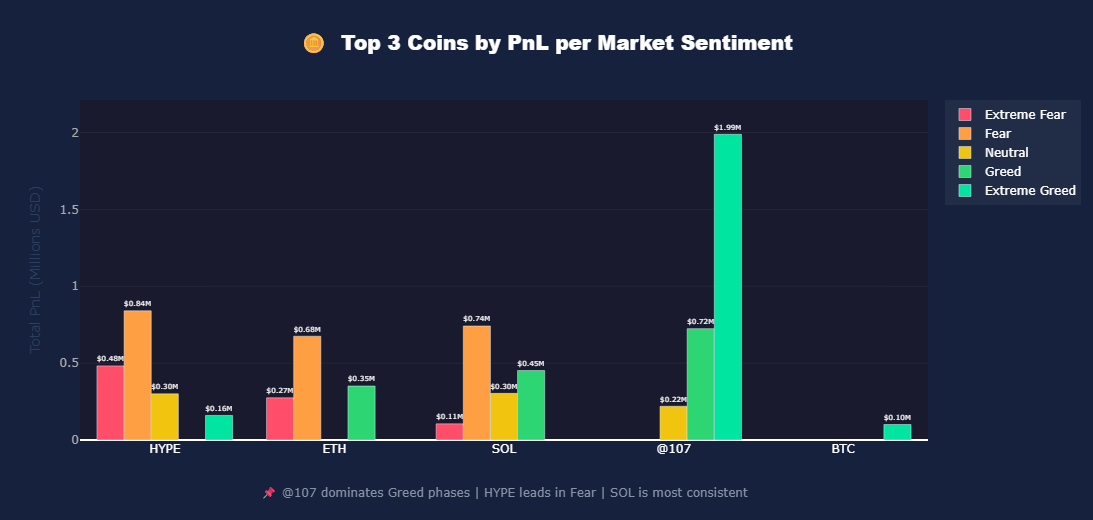

In [53]:
# ── CHART: Top Coin per Sentiment ─────────────────────────────────────────────
import plotly.graph_objects as go

fig = go.Figure()

sentiment_colors = {
    'Extreme Fear'  : '#ff4d6a',
    'Fear'          : '#ff9f43',
    'Neutral'       : '#f1c40f',
    'Greed'         : '#2ed573',
    'Extreme Greed' : '#00e5a0'
}

for sent in order:
    subset = best_coin_per_sentiment[best_coin_per_sentiment['classification'] == sent]
    fig.add_trace(go.Bar(
        name        = sent,
        x           = subset['coin'],
        y           = subset['closed_pnl'] / 1e6,
        marker_color= sentiment_colors[sent],
        text        = [f"${v/1e6:.2f}M" for v in subset['closed_pnl']],
        textposition= 'outside',
        textfont    = dict(size=11, color='white'),
    ))

fig.update_layout(
    title       = dict(
        text    = '🪙  Top 3 Coins by PnL per Market Sentiment',
        font    = dict(size=20, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    barmode     = 'group',
    paper_bgcolor='#16213e',
    plot_bgcolor ='#1a1a2e',
    xaxis       = dict(tickfont=dict(color='white', size=12), showgrid=False),
    yaxis       = dict(
        title   = 'Total PnL (Millions USD)',
        tickfont= dict(color='#aaa'),
        showgrid= True,
        gridcolor='rgba(255,255,255,0.05)'
    ),
    legend      = dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    height      = 520,
    margin      = dict(t=100, b=80, l=80, r=40),
    annotations = [dict(
        text    = '📌 @107 dominates Greed phases | HYPE leads in Fear | SOL is most consistent',
        xref='paper', yref='paper',
        x=0.5, y=-0.18,
        showarrow=False,
        font    = dict(size=12, color='#8892a4'),
        xanchor ='center'
    )]
)
fig.show()
fig.write_html('chart_coin_sentiment.html')

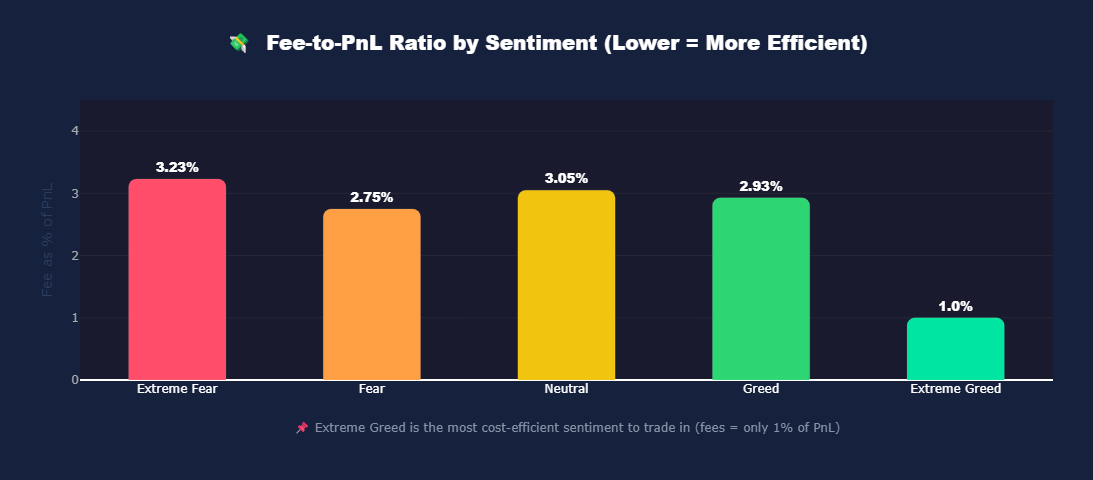

✅ Both charts saved!


In [54]:
# ── CHART: Fee-to-PnL Ratio by Sentiment ──────────────────────────────────────
fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x           = fee_analysis['classification'].tolist(),
    y           = fee_analysis['fee_to_pnl_ratio'],
    marker      = dict(
        color   = ['#ff4d6a','#ff9f43','#f1c40f','#2ed573','#00e5a0'],
        cornerradius=8,
        line    = dict(color='rgba(255,255,255,0.1)', width=1)
    ),
    text        = [f"{v}%" for v in fee_analysis['fee_to_pnl_ratio']],
    textposition= 'outside',
    textfont    = dict(size=13, color='white', family='Arial Black'),
    width       = 0.5
))

fig2.update_layout(
    title       = dict(
        text    = '💸  Fee-to-PnL Ratio by Sentiment (Lower = More Efficient)',
        font    = dict(size=20, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor='#16213e',
    plot_bgcolor ='#1a1a2e',
    xaxis       = dict(tickfont=dict(color='white', size=12), showgrid=False),
    yaxis       = dict(
        title   = 'Fee as % of PnL',
        tickfont= dict(color='#aaa'),
        showgrid= True,
        gridcolor='rgba(255,255,255,0.05)',
        range   = [0, 4.5]
    ),
    height      = 480,
    margin      = dict(t=100, b=100, l=80, r=40),
    showlegend  = False,
    annotations = [dict(
        text    = '📌 Extreme Greed is the most cost-efficient sentiment to trade in (fees = only 1% of PnL)',
        xref='paper', yref='paper',
        x=0.5, y=-0.2,
        showarrow=False,
        font    = dict(size=12, color='#8892a4'),
        xanchor ='center'
    )]
)
fig2.show()
fig2.write_html('chart_fee_ratio.html')

print("✅ Both charts saved!")

In [55]:
# ── BUY vs SELL PnL ANALYSIS ─────────────────────────────────────────────────
direction_analysis = merged.groupby(['classification', 'direction']).agg(
    total_pnl  = ('closed_pnl', 'sum'),
    avg_pnl    = ('closed_pnl', 'mean'),
    num_trades = ('closed_pnl', 'count')
).reset_index()

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
direction_analysis['classification'] = pd.Categorical(
    direction_analysis['classification'], categories=order, ordered=True
)
direction_analysis = direction_analysis.sort_values(['classification', 'direction'])
print(direction_analysis.to_string(index=False))

classification                 direction     total_pnl       avg_pnl  num_trades
  Extreme Fear                       Buy  0.000000e+00      0.000000         807
  Extreme Fear                Close Long  5.067528e+05     81.197371        6241
  Extreme Fear               Close Short  3.846385e+05    123.400238        3117
  Extreme Fear              Long > Short  6.659778e+00      1.331956           5
  Extreme Fear                 Open Long  0.000000e+00      0.000000        7005
  Extreme Fear                Open Short  0.000000e+00      0.000000        3174
  Extreme Fear                      Sell -1.406926e+05   -135.021730        1042
  Extreme Fear              Short > Long -1.159510e+04  -1932.516940           6
  Extreme Fear      Spot Dust Conversion  0.000000e+00      0.000000           3
          Fear                       Buy  0.000000e+00      0.000000        3207
          Fear                Close Long  1.432582e+06     83.000111       17260
          Fear              

In [57]:
# ── COIN-LEVEL WIN RATE BY SENTIMENT ─────────────────────────────────────────
# Which coins have the highest win rate in each sentiment?

coin_winrate = merged.groupby(['classification', 'coin']).agg(
    win_rate   = ('is_win', 'mean'),
    num_trades = ('is_win', 'count'),
    total_pnl  = ('closed_pnl', 'sum')
).reset_index()

# Filter coins with at least 20 trades per sentiment (remove noise)
coin_winrate = coin_winrate[coin_winrate['num_trades'] >= 20]
coin_winrate['win_rate_pct'] = (coin_winrate['win_rate'] * 100).round(2)

# Top 5 coins per sentiment by win rate
top_coin_winrate = (
    coin_winrate
    .sort_values(['classification', 'win_rate_pct'], ascending=[True, False])
    .groupby('classification')
    .head(5)
)

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
top_coin_winrate['classification'] = pd.Categorical(
    top_coin_winrate['classification'], categories=order, ordered=True
)
top_coin_winrate = top_coin_winrate.sort_values(['classification', 'win_rate_pct'], ascending=[True, False])

print(top_coin_winrate[['classification', 'coin', 'win_rate_pct', 'num_trades', 'total_pnl']].to_string(index=False))

classification    coin  win_rate_pct  num_trades    total_pnl
  Extreme Fear    RUNE         96.61          59  3843.260480
  Extreme Fear   JELLY         96.39          83  3218.978582
  Extreme Fear   GRASS         80.88          68  1036.457046
  Extreme Fear MELANIA         78.48         446 97379.167198
  Extreme Fear     SUI         61.04         249 44788.991651
          Fear    @152        100.00          88     0.599998
          Fear    @153        100.00          28     0.577077
          Fear     MKR         96.00          25  1333.457100
          Fear   EIGEN         95.56          45 13303.436003
          Fear    MOVE         94.12          85  2656.591555
       Neutral     ZRO        100.00          25 36172.380520
       Neutral     OGN         99.61         258  1752.668422
       Neutral    AVAX         95.45          22 35440.071585
       Neutral     TST         90.82          98  3535.193292
       Neutral   AIXBT         78.98         176 21990.866694
        

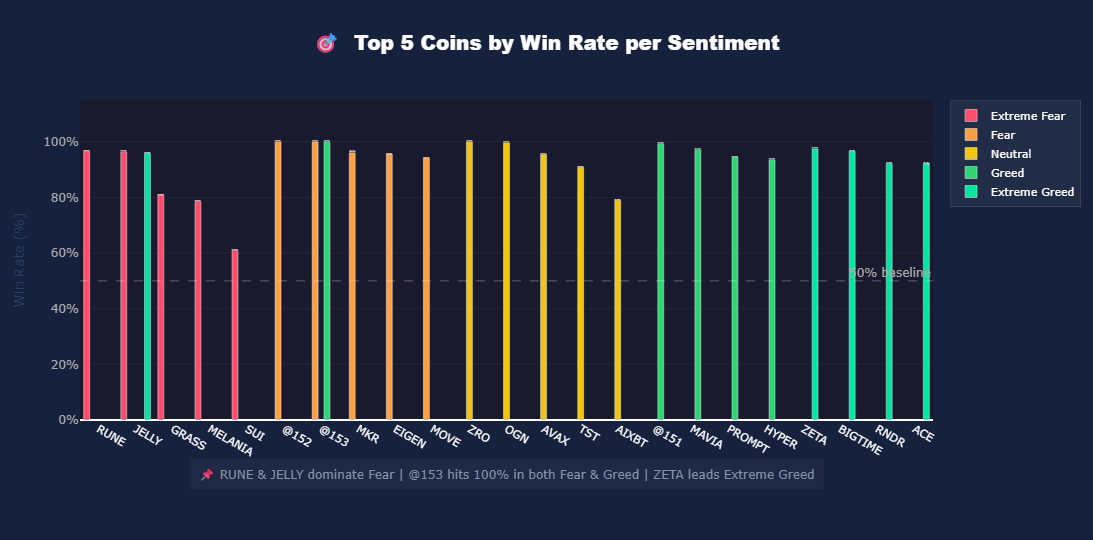

✅ Coin win rate chart saved!


In [58]:
# ── CHART: Coin Win Rate by Sentiment ────────────────────────────────────────
import plotly.graph_objects as go

sentiment_colors = {
    'Extreme Fear'  : '#ff4d6a',
    'Fear'          : '#ff9f43',
    'Neutral'       : '#f1c40f',
    'Greed'         : '#2ed573',
    'Extreme Greed' : '#00e5a0'
}

fig = go.Figure()

for sent in order:
    subset = top_coin_winrate[top_coin_winrate['classification'] == sent]
    fig.add_trace(go.Bar(
        name         = sent,
        x            = subset['coin'],
        y            = subset['win_rate_pct'],
        marker_color = sentiment_colors[sent],
        text         = [f"{v}%" for v in subset['win_rate_pct']],
        textposition = 'outside',
        textfont     = dict(size=10, color='white'),
        customdata   = subset[['num_trades', 'total_pnl']].values,
        hovertemplate= (
            '<b>%{x}</b><br>'
            'Sentiment: <b>' + sent + '</b><br>'
            'Win Rate: <b>%{y:.2f}%</b><br>'
            'Trades: <b>%{customdata[0]}</b><br>'
            'Total PnL: <b>$%{customdata[1]:,.0f}</b>'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    title       = dict(
        text    = '🎯  Top 5 Coins by Win Rate per Sentiment',
        font    = dict(size=20, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    barmode     = 'group',
    paper_bgcolor='#16213e',
    plot_bgcolor ='#1a1a2e',
    xaxis       = dict(
        tickfont    = dict(color='white', size=11),
        showgrid    = False,
    ),
    yaxis       = dict(
        title       = 'Win Rate (%)',
        tickfont    = dict(color='#aaa'),
        showgrid    = True,
        gridcolor   = 'rgba(255,255,255,0.05)',
        range       = [0, 115],
        ticksuffix  = '%'
    ),
    legend      = dict(
        font        = dict(color='white', size=11),
        bgcolor     = 'rgba(255,255,255,0.05)',
        bordercolor = 'rgba(255,255,255,0.1)',
        borderwidth = 1
    ),
    height      = 540,
    margin      = dict(t=100, b=120, l=80, r=40),
    hoverlabel  = dict(
        bgcolor     = '#0f3460',
        font_size   = 13,
        font_color  = 'white'
    ),
    annotations = [dict(
        text    = '📌 RUNE & JELLY dominate Fear | @153 hits 100% in both Fear & Greed | ZETA leads Extreme Greed',
        xref='paper', yref='paper',
        x=0.5, y=-0.22,
        showarrow   = False,
        font        = dict(size=12, color='#8892a4'),
        xanchor     = 'center',
        bgcolor     = 'rgba(255,255,255,0.04)',
        borderpad   = 8
    )]
)

# 50% baseline
fig.add_hline(
    y=50,
    line_dash       = 'dash',
    line_color      = 'rgba(255,255,255,0.2)',
    line_width      = 1.5,
    annotation_text = '50% baseline',
    annotation_font_color='#aaa',
    annotation_position='top right'
)

fig.show()
fig.write_html('chart_coin_winrate_sentiment.html')
print("✅ Coin win rate chart saved!")

In [71]:

# Set default renderer for Jupyter
pio.renderers.default = "iframe"

# ── 1. Pearson & Spearman correlation ─────────────────────────────────────
pearson_r,  pearson_p  = stats.pearsonr(merged['value'], merged['closed_pnl'])
spearman_r, spearman_p = stats.spearmanr(merged['value'], merged['closed_pnl'])

print("=" * 50)
print("CORRELATION: Fear/Greed Index Value vs Closed PnL")
print("=" * 50)
print(f"Pearson  r = {pearson_r:.4f}  |  p-value = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.4f}  |  p-value = {spearman_p:.4f}")
print()

if abs(spearman_r) < 0.1:
    strength = "negligible"
elif abs(spearman_r) < 0.3:
    strength = "weak"
elif abs(spearman_r) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if spearman_r > 0 else "negative"
print(f"Interpretation: {strength} {direction} relationship")

# ── 2. Scatter plot with regression line ──────────────────────────────────
slope, intercept, r_val, p_val, std_err = stats.linregress(
    merged['value'], merged['closed_pnl']
)

x_line = np.linspace(merged['value'].min(), merged['value'].max(), 200)
y_line = slope * x_line + intercept

sentiment_colors = merged['classification'].map({
    'Extreme Fear': '#ff4757',
    'Fear':         '#ff9f43',
    'Neutral':      '#f1c40f',
    'Greed':        '#2ed573',
    'Extreme Greed':'#00e5a0'
})

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=merged['value'],
    y=merged['closed_pnl'],
    mode='markers',
    marker=dict(color=sentiment_colors, size=4, opacity=0.35),
    name='Trades',
    hovertemplate='Index: %{x}<br>PnL: $%{y:,.2f}<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines',
    line=dict(color='white', width=2, dash='dash'),
    name=f'Regression (r={r_val:.3f})'
))

fig.update_layout(
    title=dict(
        text=f'📈 Fear/Greed Index Value vs Closed PnL  |  Spearman r = {spearman_r:.4f}  |  p = {spearman_p:.4f}',
        font=dict(size=18, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title='Fear/Greed Index Value (0=Extreme Fear, 100=Extreme Greed)',
        tickfont=dict(color='white'),
        showgrid=True,
        gridcolor='rgba(255,255,255,0.05)'
    ),
    yaxis=dict(
        title='Closed PnL (USD)',
        tickfont=dict(color='white'),
        showgrid=True,
        gridcolor='rgba(255,255,255,0.05)'
    ),
    paper_bgcolor='#16213e',
    plot_bgcolor='#1a1a2e',
    height=520,
    legend=dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=90, b=80, l=80, r=40)
)

fig.show()  # uses "iframe" renderer set above
fig.write_html('chart_correlation.html')
print("✅ Saved: chart_correlation.html")

CORRELATION: Fear/Greed Index Value vs Closed PnL
Pearson  r = 0.0081  |  p-value = 0.0002
Spearman r = 0.0381  |  p-value = 0.0000

Interpretation: negligible positive relationship


✅ Saved: chart_correlation.html


In [70]:


pio.renderers.default = "iframe"

# ── HELPER FUNCTIONS ───────────────────────────────────────────────────────

def sharpe_ratio(pnl_series, risk_free=0):
    excess = pnl_series - risk_free
    return excess.mean() / excess.std() if excess.std() != 0 else 0

def max_drawdown(pnl_series):
    cumulative  = pnl_series.cumsum()
    rolling_max = cumulative.cummax()
    return (cumulative - rolling_max).min()

def calmar_ratio(pnl_series):
    mdd = max_drawdown(pnl_series)
    return pnl_series.sum() / abs(mdd) if mdd != 0 else 0


# ── 1. RISK METRICS BY SENTIMENT BAND ─────────────────────────────────────

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

risk_sentiment = []
for sentiment in sentiment_order:
    subset = merged[merged['classification'] == sentiment]['closed_pnl']
    if len(subset) < 5:
        continue
    risk_sentiment.append({
        'Sentiment':    sentiment,
        'Sharpe Ratio': round(sharpe_ratio(subset), 4),
        'Max Drawdown': round(max_drawdown(subset), 2),
        'Calmar Ratio': round(calmar_ratio(subset), 4),
        'Total PnL':    round(subset.sum(), 2),
        'Trade Count':  len(subset),
    })

risk_sentiment_df = pd.DataFrame(risk_sentiment)
print("=" * 65)
print("RISK-ADJUSTED PERFORMANCE BY SENTIMENT")
print("=" * 65)
print(risk_sentiment_df.to_string(index=False))











RISK-ADJUSTED PERFORMANCE BY SENTIMENT
    Sentiment  Sharpe Ratio  Max Drawdown  Calmar Ratio  Total PnL  Trade Count
 Extreme Fear        0.0304    -217850.31        3.3927  739110.25        21400
         Fear        0.0580    -113383.72       29.6088 3357155.44        61837
      Neutral        0.0663    -132639.36        9.7476 1292920.68        37686
        Greed        0.0383    -460774.42        4.6663 2150129.27        50303
Extreme Greed        0.0885    -152323.10       17.8251 2715171.31        39992


In [64]:
# ── 2. RISK METRICS BY TOP TRADER ─────────────────────────────────────────
trader_counts = merged.groupby('account')['closed_pnl'].count()
top_traders   = trader_counts[trader_counts >= 10].nlargest(15).index

risk_trader = []
for trader in top_traders:
    subset = merged[merged['account'] == trader]['closed_pnl']
    risk_trader.append({
        'Trader':       trader,
        'Sharpe Ratio': round(sharpe_ratio(subset), 4),
        'Max Drawdown': round(max_drawdown(subset), 2),
        'Calmar Ratio': round(calmar_ratio(subset), 4),
        'Total PnL':    round(subset.sum(), 2),
        'Trade Count':  len(subset),
    })

risk_trader_df = pd.DataFrame(risk_trader).sort_values('Sharpe Ratio', ascending=False)
print("\n" + "=" * 65)
print("RISK-ADJUSTED PERFORMANCE — TOP 15 TRADERS")
print("=" * 65)
print(risk_trader_df.to_string(index=False))



RISK-ADJUSTED PERFORMANCE — TOP 15 TRADERS
                                    Trader  Sharpe Ratio  Max Drawdown  Calmar Ratio  Total PnL  Trade Count
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4        0.2221     -22517.28       16.8358  379095.41         9893
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4        0.1819      -7577.27       89.4448  677747.05         4356
0x47add9a56df66b524d5e2c1993a43cde53b6ed85        0.1374     -19322.09        5.3485  103343.72         8519
0x513b8629fe877bb581bf244e326a047b249c4ff1        0.1074     -84803.25        9.9103  840422.56        12236
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23        0.1059     -10883.68      196.9354 2143382.60        14733
0xa0feb3725a9335f49874d7cd8eaad6be45b27416        0.0998      -8766.77       12.1257  106302.88        15605
0x083384f897ee0f19899168e3b1bec365f52a9012        0.0893    -327934.10        4.8797 1600229.82         3818
0x28736f43f1e871e6aa8b1148d38d4994275d72c4        0.0879     -20849.97        6.3532

In [68]:
# ── 3. CHART A — Sharpe + Max Drawdown by Sentiment (dual axis) ───────────

sentiment_colors = {
    'Extreme Fear': '#ff4757',
    'Fear':         '#ff9f43',
    'Neutral':      '#f1c40f',
    'Greed':        '#2ed573',
    'Extreme Greed':'#00e5a0'
}
bar_colors = [sentiment_colors[s] for s in risk_sentiment_df['Sentiment']]

fig1 = make_subplots(specs=[[{"secondary_y": True}]])

fig1.add_trace(go.Bar(
    x=risk_sentiment_df['Sentiment'],
    y=risk_sentiment_df['Sharpe Ratio'],
    name='Sharpe Ratio',
    marker_color=bar_colors,
    opacity=0.85,
    text=risk_sentiment_df['Sharpe Ratio'].round(3),
    textposition='outside',
    textfont=dict(color='white')
), secondary_y=False)

fig1.add_trace(go.Scatter(
    x=risk_sentiment_df['Sentiment'],
    y=risk_sentiment_df['Max Drawdown'],
    name='Max Drawdown (USD)',
    mode='lines+markers',
    line=dict(color='#ff6b9d', width=2.5, dash='dot'),
    marker=dict(size=9, color='#ff6b9d'),
), secondary_y=True)

fig1.update_layout(
    title=dict(
        text='⚖️ Risk-Adjusted Performance by Sentiment  |  Sharpe Ratio & Max Drawdown',
        font=dict(size=17, color='white'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=480,
    legend=dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=80, b=60, l=80, r=80),
    xaxis=dict(tickfont=dict(color='white'), showgrid=False),
)
fig1.update_yaxes(title_text='Sharpe Ratio',      tickfont=dict(color='white'),    secondary_y=False)
fig1.update_yaxes(title_text='Max Drawdown (USD)', tickfont=dict(color='#ff6b9d'), secondary_y=True)

fig1.show()
fig1.write_html('chart_risk_sentiment.html')
print("✅ Saved: chart_risk_sentiment.html")


✅ Saved: chart_risk_sentiment.html


In [66]:
# ── 4. CHART B — Top Traders: Sharpe vs Total PnL bubble chart ────────────

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=risk_trader_df['Total PnL'],
    y=risk_trader_df['Sharpe Ratio'],
    mode='markers+text',
    marker=dict(
        size=np.sqrt(risk_trader_df['Trade Count']) * 4,
        color=risk_trader_df['Sharpe Ratio'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(
            title=dict(                      # ← FIXED: was titlefont=dict(...)
                text='Sharpe',
                font=dict(color='white')
            ),
            tickfont=dict(color='white')
        ),
        line=dict(color='white', width=0.5)
    ),
    text=risk_trader_df['Trader'].str[:8],
    textposition='top center',
    textfont=dict(color='white', size=9),
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Total PnL: $%{x:,.0f}<br>'
        'Sharpe: %{y:.3f}<br>'
        '<extra></extra>'
    )
))

fig2.add_hline(y=0, line_dash='dash', line_color='rgba(255,255,255,0.3)')
fig2.add_vline(x=0, line_dash='dash', line_color='rgba(255,255,255,0.3)')

fig2.update_layout(
    title=dict(
        text='🏆 Top Traders — Sharpe Ratio vs Total PnL  (bubble size = trade count)',
        font=dict(size=17, color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Total PnL (USD)', tickfont=dict(color='white'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    yaxis=dict(title='Sharpe Ratio',    tickfont=dict(color='white'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=520,
    margin=dict(t=80, b=60, l=80, r=40)
)

fig2.show()
fig2.write_html('chart_risk_traders.html')
print("✅ Saved: chart_risk_traders.html")



✅ Saved: chart_risk_traders.html


In [67]:
# ── 5. CHART C — Cumulative PnL curves by sentiment ───────────────────────

fig3 = go.Figure()

for sentiment in sentiment_order:
    subset = merged[merged['classification'] == sentiment]['closed_pnl'].reset_index(drop=True)
    if len(subset) < 5:
        continue
    cumulative = subset.cumsum()
    fig3.add_trace(go.Scatter(
        x=cumulative.index,
        y=cumulative.values,
        mode='lines',
        name=sentiment,
        line=dict(color=sentiment_colors[sentiment], width=2),
        hovertemplate=f'{sentiment}<br>Trade #%{{x}}<br>Cum PnL: $%{{y:,.0f}}<extra></extra>'
    ))

fig3.update_layout(
    title=dict(
        text='📉 Cumulative PnL Curves by Sentiment  |  Drawdown Visualized',
        font=dict(size=17, color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(title='Trade Number', tickfont=dict(color='white'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    yaxis=dict(title='Cumulative PnL (USD)', tickfont=dict(color='white'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=480,
    legend=dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=80, b=60, l=80, r=40)
)

fig3.show()
fig3.write_html('chart_cumulative_pnl.html')
print("✅ Saved: chart_cumulative_pnl.html")

✅ Saved: chart_cumulative_pnl.html


In [72]:
pio.renderers.default = "iframe"

# ── 1. OVERVIEW — Understand the start_position column ────────────────────

print("=" * 55)
print("START POSITION COLUMN — OVERVIEW")
print("=" * 55)
print(f"Total rows          : {len(merged)}")
print(f"Null values         : {merged['start_position'].isnull().sum()}")
print(f"Zero values         : {(merged['start_position'] == 0).sum()}")
print(f"Non-zero values     : {(merged['start_position'] != 0).sum()}")
print(f"Min                 : {merged['start_position'].min():,.2f}")
print(f"Max                 : {merged['start_position'].max():,.2f}")
print(f"Mean                : {merged['start_position'].mean():,.2f}")
print(f"Median              : {merged['start_position'].median():,.2f}")
print()


START POSITION COLUMN — OVERVIEW
Total rows          : 211218
Null values         : 0
Zero values         : 4085
Non-zero values     : 207133
Min                 : -14,334,629.00
Max                 : 30,509,482.00
Mean                : -29,946.71
Median              : 84.77



In [77]:
# ── BUY vs SELL PnL ANALYSIS (using 'side' column) ───────────────────────
direction_analysis = merged.groupby(['classification', 'side']).agg(
    total_pnl  = ('closed_pnl', 'sum'),
    avg_pnl    = ('closed_pnl', 'mean'),
    num_trades = ('closed_pnl', 'count')
).reset_index()

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
direction_analysis['classification'] = pd.Categorical(
    direction_analysis['classification'], categories=order, ordered=True
)
direction_analysis = direction_analysis.sort_values(['classification', 'side'])

# ── CHART: BUY vs SELL Average PnL by Sentiment ───────────────────────────
buy_data  = direction_analysis[direction_analysis['side'] == 'BUY'].set_index('classification')
sell_data = direction_analysis[direction_analysis['side'] == 'SELL'].set_index('classification')

buy_avg  = [float(buy_data.loc[s, 'avg_pnl'])   if s in buy_data.index  else 0 for s in order]
sell_avg = [float(sell_data.loc[s, 'avg_pnl'])  if s in sell_data.index else 0 for s in order]
buy_cnt  = [int(buy_data.loc[s, 'num_trades'])  if s in buy_data.index  else 0 for s in order]
sell_cnt = [int(sell_data.loc[s, 'num_trades']) if s in sell_data.index else 0 for s in order]

print("BUY avg PnL per sentiment: ", buy_avg)
print("SELL avg PnL per sentiment:", sell_avg)

fig = go.Figure()

fig.add_trace(go.Bar(
    name='BUY',
    x=order,
    y=buy_avg,
    marker=dict(color='#2ed573', cornerradius=8,
                line=dict(color='rgba(255,255,255,0.15)', width=1.5)),
    text=[f'${v:.2f}' for v in buy_avg],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    width=0.35,
    customdata=buy_cnt,
    hovertemplate='<b>BUY — %{x}</b><br>Avg PnL: $%{y:.2f}<br>Trades: %{customdata}<extra></extra>'
))

fig.add_trace(go.Bar(
    name='SELL',
    x=order,
    y=sell_avg,
    marker=dict(color='#ff4757', cornerradius=8,
                line=dict(color='rgba(255,255,255,0.15)', width=1.5)),
    text=[f'${v:.2f}' for v in sell_avg],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    width=0.35,
    customdata=sell_cnt,
    hovertemplate='<b>SELL — %{x}</b><br>Avg PnL: $%{y:.2f}<br>Trades: %{customdata}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='📊 BUY vs SELL — Average PnL by Market Sentiment',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    barmode='group',
    xaxis=dict(
        tickfont=dict(color='white', size=12),
        showgrid=False,
        categoryorder='array',
        categoryarray=order
    ),
    yaxis=dict(
        title='Average Closed PnL (USD)',
        tickfont=dict(color='#aaa'),
        showgrid=True,
        gridcolor='rgba(255,255,255,0.05)',
        zeroline=True,
        zerolinecolor='rgba(255,255,255,0.2)'
    ),
    paper_bgcolor='#16213e',
    plot_bgcolor='#1a1a2e',
    height=560,
    legend=dict(font=dict(color='white', size=13), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=100, b=120, l=80, r=40),
    hoverlabel=dict(bgcolor='#0f3460', font_size=13, font_color='white'),
    annotations=[dict(
        text='📌 Compare whether BUY or SELL trades are more profitable in each sentiment regime',
        xref='paper', yref='paper',
        x=0.5, y=-0.22,
        showarrow=False,
        font=dict(size=12, color='#8892a4'),
        xanchor='center',
        bgcolor='rgba(255,255,255,0.04)',
        borderpad=8
    )]
)

fig.add_hline(y=0, line_dash='dash', line_color='rgba(255,255,255,0.25)', line_width=1.5)

fig.show()
fig.write_html('chart_buy_vs_sell.html')
print("✅ Saved: chart_buy_vs_sell.html")

BUY avg PnL per sentiment:  [34.11462658445359, 63.92710403230922, 29.227428517581316, 25.002302417154947, 10.498927234057971]
SELL avg PnL per sentiment: [34.9801057610129, 45.04964052916019, 39.45640775765347, 59.6910906342364, 114.58464339261745]


✅ Saved: chart_buy_vs_sell.html


In [78]:
# ── START POSITION DEEP DIVE ──────────────────────────────────────────────
from scipy import stats as scipy_stats

pio.renderers.default = "iframe"
# ── 1. Create position size buckets ───────────────────────────────────────
merged['pos_bucket'] = pd.cut(
    merged['start_position'].abs(),
    bins=[-0.001, 0, 1, 10, 50, 100, float('inf')],
    labels=['Zero', 'Micro (<1)', 'Small (1-10)', 'Medium (10-50)', 'Large (50-100)', 'XLarge (100+)']
)

bucket_analysis = merged.groupby('pos_bucket', observed=True).agg(
    total_pnl  = ('closed_pnl', 'sum'),
    avg_pnl    = ('closed_pnl', 'mean'),
    win_rate   = ('is_win', 'mean'),
    num_trades = ('closed_pnl', 'count'),
    avg_pos    = ('start_position', 'mean')
).reset_index()
bucket_analysis['win_rate_pct'] = (bucket_analysis['win_rate'] * 100).round(2)

print("=" * 65)
print("START POSITION SIZE vs PERFORMANCE")
print("=" * 65)
print(bucket_analysis[['pos_bucket','num_trades','avg_pnl','win_rate_pct','total_pnl']].to_string(index=False))

START POSITION SIZE vs PERFORMANCE
    pos_bucket  num_trades   avg_pnl  win_rate_pct    total_pnl
          Zero        4085  0.000000          0.00 0.000000e+00
    Micro (<1)       10482 14.583622         29.14 1.528655e+05
  Small (1-10)       13259 24.833068         35.86 3.292616e+05
Medium (10-50)       13397 31.461323         37.35 4.214873e+05
Large (50-100)        6396 41.784510         42.21 2.672537e+05
 XLarge (100+)      163599 55.523681         43.61 9.083619e+06


In [79]:
# ── 2. Correlation: position size vs PnL ──────────────────────────────────
nonzero = merged[merged['start_position'] != 0].copy()
nonzero['abs_position'] = nonzero['start_position'].abs()

pearson_r,  pearson_p  = scipy_stats.pearsonr(nonzero['abs_position'],  nonzero['closed_pnl'])
spearman_r, spearman_p = scipy_stats.spearmanr(nonzero['abs_position'], nonzero['closed_pnl'])

print(f"\nCorrelation — Position Size vs Closed PnL")
print(f"Pearson  r = {pearson_r:.4f}  |  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.4f}  |  p = {spearman_p:.4f}")



Correlation — Position Size vs Closed PnL
Pearson  r = -0.0025  |  p = 0.2572
Spearman r = 0.0624  |  p = 0.0000


In [80]:
# ── 3. CHART A — Avg PnL & Win Rate by Position Bucket ────────────────────
from plotly.subplots import make_subplots

fig1 = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '<b>Average PnL by Position Size</b>',
        '<b>Win Rate (%) by Position Size</b>'
    ],
    horizontal_spacing=0.12
)

bucket_colors = ['#636e72', '#74b9ff', '#0984e3', '#fdcb6e', '#e17055', '#d63031']

# Avg PnL
fig1.add_trace(go.Bar(
    x=bucket_analysis['pos_bucket'].astype(str),
    y=bucket_analysis['avg_pnl'],
    marker=dict(color=bucket_colors, cornerradius=8,
                line=dict(color='rgba(255,255,255,0.1)', width=1)),
    text=[f'${v:.2f}' for v in bucket_analysis['avg_pnl']],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    customdata=bucket_analysis['num_trades'],
    hovertemplate='<b>%{x}</b><br>Avg PnL: $%{y:.2f}<br>Trades: %{customdata}<extra></extra>',
    showlegend=False
), row=1, col=1)

# Win Rate
fig1.add_trace(go.Bar(
    x=bucket_analysis['pos_bucket'].astype(str),
    y=bucket_analysis['win_rate_pct'],
    marker=dict(color=bucket_colors, cornerradius=8,
                line=dict(color='rgba(255,255,255,0.1)', width=1)),
    text=[f'{v:.1f}%' for v in bucket_analysis['win_rate_pct']],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    customdata=bucket_analysis['num_trades'],
    hovertemplate='<b>%{x}</b><br>Win Rate: %{y:.2f}%<br>Trades: %{customdata}<extra></extra>',
    showlegend=False
), row=1, col=2)

fig1.update_layout(
    title=dict(
        text='📐 Start Position Size vs Trading Performance',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=520,
    margin=dict(t=110, b=120, l=70, r=40),
    annotations=[
        dict(text='<b>Average PnL by Position Size</b>',
             xref='paper', yref='paper', x=0.22, y=1.08,
             showarrow=False, font=dict(color='white', size=13), xanchor='center'),
        dict(text='<b>Win Rate (%) by Position Size</b>',
             xref='paper', yref='paper', x=0.78, y=1.08,
             showarrow=False, font=dict(color='white', size=13), xanchor='center'),
        dict(
            text=f'📌 Spearman r = {spearman_r:.4f} | Larger positions do not guarantee better PnL',
            xref='paper', yref='paper', x=0.5, y=-0.22,
            showarrow=False, font=dict(size=12, color='#8892a4'),
            xanchor='center', bgcolor='rgba(255,255,255,0.04)', borderpad=8
        )
    ]
)

for col in [1, 2]:
    fig1.update_xaxes(tickfont=dict(color='white', size=10), showgrid=False,
                      tickangle=-20, row=1, col=col)
    fig1.update_yaxes(tickfont=dict(color='#aaa'), showgrid=True,
                      gridcolor='rgba(255,255,255,0.05)', row=1, col=col)

fig1.add_hline(y=0, line_dash='dash', line_color='rgba(255,255,255,0.2)', row=1, col=1)
fig1.add_hline(y=50, line_dash='dash', line_color='rgba(255,255,255,0.2)', row=1, col=2)

fig1.show()
fig1.write_html('chart_position_performance.html')
print("✅ Saved: chart_position_performance.html")



✅ Saved: chart_position_performance.html


In [81]:
# ── 4. CHART B — Position Size Distribution by Sentiment ──────────────────
pos_sentiment = merged[merged['start_position'] != 0].groupby('classification').agg(
    avg_pos_size = ('start_position', lambda x: x.abs().mean()),
    median_pos   = ('start_position', lambda x: x.abs().median()),
    num_trades   = ('start_position', 'count')
).reset_index()

sent_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sent_colors = ['#ff4757', '#ff9f43', '#f1c40f', '#2ed573', '#00e5a0']

pos_sentiment['classification'] = pd.Categorical(
    pos_sentiment['classification'], categories=sent_order, ordered=True
)
pos_sentiment = pos_sentiment.sort_values('classification')

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    name='Avg Position Size',
    x=pos_sentiment['classification'].astype(str),
    y=pos_sentiment['avg_pos_size'],
    marker=dict(color=sent_colors, cornerradius=8,
                line=dict(color='rgba(255,255,255,0.1)', width=1), opacity=0.9),
    text=[f'{v:.2f}' for v in pos_sentiment['avg_pos_size']],
    textposition='outside',
    textfont=dict(size=12, color='white', family='Arial Black'),
    hovertemplate='<b>%{x}</b><br>Avg Position: %{y:.2f}<br><extra></extra>'
))

fig2.add_trace(go.Scatter(
    name='Median Position Size',
    x=pos_sentiment['classification'].astype(str),
    y=pos_sentiment['median_pos'],
    mode='lines+markers',
    line=dict(color='#a29bfe', width=2.5, dash='dot'),
    marker=dict(size=10, color='#a29bfe'),
    hovertemplate='<b>%{x}</b><br>Median Position: %{y:.2f}<extra></extra>'
))

fig2.update_layout(
    title=dict(
        text='📦 Average Position Size by Market Sentiment',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(tickfont=dict(color='white', size=12), showgrid=False),
    yaxis=dict(title='Position Size (absolute)', tickfont=dict(color='#aaa'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=500,
    legend=dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=100, b=100, l=80, r=40),
    annotations=[dict(
        text='📌 Do traders take larger positions during Greed? This chart reveals risk appetite by sentiment.',
        xref='paper', yref='paper', x=0.5, y=-0.18,
        showarrow=False, font=dict(size=12, color='#8892a4'),
        xanchor='center', bgcolor='rgba(255,255,255,0.04)', borderpad=8
    )]
)

fig2.show()
fig2.write_html('chart_position_by_sentiment.html')
print("✅ Saved: chart_position_by_sentiment.html")

✅ Saved: chart_position_by_sentiment.html


In [83]:
# ── LEVERAGE ANALYSIS ─────────────────────────────────────────────────────
pio.renderers.default = "iframe"

# ── 0. SAFETY CHECK — find the correct leverage column name ───────────────
print("Available columns in merged:")
print(merged.columns.tolist())

# Auto-detect leverage column (handles casing & merge suffixes)
lev_candidates = [c for c in merged.columns if 'leverage' in c.lower()]
if not lev_candidates:
    raise ValueError("❌ No 'leverage' column found! Check your merge step.")
elif len(lev_candidates) > 1:
    print(f"⚠️  Multiple leverage columns found: {lev_candidates}")
    print(f"   Using: '{lev_candidates[0]}' — change below if needed.")

LEV_COL = lev_candidates[0]  # ← change manually if wrong, e.g. LEV_COL = 'leverage_x'
print(f"✅ Using leverage column: '{LEV_COL}'")

# Rename to 'leverage' so rest of code works unchanged
if LEV_COL != 'leverage':
    merged = merged.rename(columns={LEV_COL: 'leverage'})
    print(f"   Renamed '{LEV_COL}' → 'leverage'")

# ── 1. Quick overview of leverage column ──────────────────────────────────
print("=" * 55)
print("LEVERAGE COLUMN — OVERVIEW")
print("=" * 55)
print(f"Null values     : {merged['leverage'].isnull().sum()}")
print(f"Unique values   : {merged['leverage'].nunique()}")
print(f"Min             : {merged['leverage'].min()}")
print(f"Max             : {merged['leverage'].max()}")
print(f"Mean            : {merged['leverage'].mean():.2f}")
print(f"Median          : {merged['leverage'].median():.2f}")
print(f"\nTop 10 most used leverage values:")
print(merged['leverage'].value_counts().head(10))

# ── 2. Bucket leverage into groups ────────────────────────────────────────
merged['lev_bucket'] = pd.cut(
    merged['leverage'],
    bins=[0, 2, 5, 10, 20, 50, float('inf')],
    labels=['1-2x', '3-5x', '6-10x', '11-20x', '21-50x', '50x+']
)

lev_analysis = merged.groupby('lev_bucket', observed=True).agg(
    total_pnl  = ('closed_pnl', 'sum'),
    avg_pnl    = ('closed_pnl', 'mean'),
    win_rate   = ('is_win', 'mean'),
    num_trades = ('closed_pnl', 'count'),
    avg_lev    = ('leverage', 'mean')
).reset_index()
lev_analysis['win_rate_pct'] = (lev_analysis['win_rate'] * 100).round(2)

print("\n" + "=" * 65)
print("LEVERAGE BUCKET vs PERFORMANCE")
print("=" * 65)
print(lev_analysis[['lev_bucket','num_trades','avg_lev','avg_pnl','win_rate_pct','total_pnl']].to_string(index=False))

# ── 3. Correlation: leverage vs PnL ───────────────────────────────────────
lev_clean = merged[merged['leverage'].notna()]
pearson_r,  pearson_p  = scipy_stats.pearsonr(lev_clean['leverage'],  lev_clean['closed_pnl'])
spearman_r, spearman_p = scipy_stats.spearmanr(lev_clean['leverage'], lev_clean['closed_pnl'])

print(f"\nCorrelation — Leverage vs Closed PnL")
print(f"Pearson  r = {pearson_r:.4f}  |  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.4f}  |  p = {spearman_p:.4f}")

# ── 4. CHART A — Avg PnL & Win Rate by Leverage Bucket ────────────────────
lev_colors = ['#00b894', '#55efc4', '#fdcb6e', '#e17055', '#d63031', '#6c5ce7']

fig1 = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '<b>Average PnL by Leverage</b>',
        '<b>Win Rate (%) by Leverage</b>'
    ],
    horizontal_spacing=0.12
)

fig1.add_trace(go.Bar(
    x=lev_analysis['lev_bucket'].astype(str),
    y=lev_analysis['avg_pnl'],
    marker=dict(color=lev_colors, cornerradius=8,
                line=dict(color='rgba(255,255,255,0.1)', width=1)),
    text=[f'${v:.2f}' for v in lev_analysis['avg_pnl']],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    customdata=lev_analysis['num_trades'],
    hovertemplate='<b>%{x}</b><br>Avg PnL: $%{y:.2f}<br>Trades: %{customdata}<extra></extra>',
    showlegend=False
), row=1, col=1)

fig1.add_trace(go.Bar(
    x=lev_analysis['lev_bucket'].astype(str),
    y=lev_analysis['win_rate_pct'],
    marker=dict(color=lev_colors, cornerradius=8,
                line=dict(color='rgba(255,255,255,0.1)', width=1)),
    text=[f'{v:.1f}%' for v in lev_analysis['win_rate_pct']],
    textposition='outside',
    textfont=dict(size=11, color='white', family='Arial Black'),
    customdata=lev_analysis['num_trades'],
    hovertemplate='<b>%{x}</b><br>Win Rate: %{y:.2f}%<br>Trades: %{customdata}<extra></extra>',
    showlegend=False
), row=1, col=2)

fig1.update_layout(
    title=dict(
        text='⚡ Leverage vs Trading Performance',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=520,
    margin=dict(t=110, b=120, l=70, r=40),
    annotations=[dict(
        text=f'📌 Spearman r = {spearman_r:.4f} | Does higher leverage destroy or boost returns?',
        xref='paper', yref='paper', x=0.5, y=-0.22,
        showarrow=False, font=dict(size=12, color='#8892a4'),
        xanchor='center', bgcolor='rgba(255,255,255,0.04)', borderpad=8
    )]
)

for col in [1, 2]:
    fig1.update_xaxes(tickfont=dict(color='white', size=11), showgrid=False, row=1, col=col)
    fig1.update_yaxes(tickfont=dict(color='#aaa'), showgrid=True,
                      gridcolor='rgba(255,255,255,0.05)', row=1, col=col)

fig1.add_hline(y=0,  line_dash='dash', line_color='rgba(255,255,255,0.2)', row=1, col=1)
fig1.add_hline(y=50, line_dash='dash', line_color='rgba(255,255,255,0.2)', row=1, col=2)

fig1.show()
fig1.write_html('chart_leverage_performance.html')
print("✅ Saved: chart_leverage_performance.html")

# ── 5. CHART B — Leverage Usage by Sentiment ──────────────────────────────
lev_sentiment = merged.groupby('classification').agg(
    avg_leverage    = ('leverage', 'mean'),
    median_leverage = ('leverage', 'median'),
    max_leverage    = ('leverage', 'max'),
    num_trades      = ('leverage', 'count')
).reset_index()

sent_order  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sent_colors = ['#ff4757', '#ff9f43', '#f1c40f', '#2ed573', '#00e5a0']

lev_sentiment['classification'] = pd.Categorical(
    lev_sentiment['classification'], categories=sent_order, ordered=True
)
lev_sentiment = lev_sentiment.sort_values('classification')

fig2 = go.Figure()

fig2.add_trace(go.Bar(
    name='Avg Leverage',
    x=lev_sentiment['classification'].astype(str),
    y=lev_sentiment['avg_leverage'],
    marker=dict(color=sent_colors, cornerradius=8, opacity=0.9,
                line=dict(color='rgba(255,255,255,0.1)', width=1)),
    text=[f'{v:.1f}x' for v in lev_sentiment['avg_leverage']],
    textposition='outside',
    textfont=dict(size=13, color='white', family='Arial Black'),
    hovertemplate='<b>%{x}</b><br>Avg Leverage: %{y:.2f}x<extra></extra>'
))

fig2.add_trace(go.Scatter(
    name='Median Leverage',
    x=lev_sentiment['classification'].astype(str),
    y=lev_sentiment['median_leverage'],
    mode='lines+markers',
    line=dict(color='#a29bfe', width=2.5, dash='dot'),
    marker=dict(size=10, color='#a29bfe'),
    hovertemplate='<b>%{x}</b><br>Median Leverage: %{y:.2f}x<extra></extra>'
))

fig2.update_layout(
    title=dict(
        text='⚡ Leverage Usage by Market Sentiment',
        font=dict(size=22, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(tickfont=dict(color='white', size=12), showgrid=False),
    yaxis=dict(title='Leverage (x)', tickfont=dict(color='#aaa'),
               showgrid=True, gridcolor='rgba(255,255,255,0.05)'),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=500,
    legend=dict(font=dict(color='white'), bgcolor='rgba(255,255,255,0.05)'),
    margin=dict(t=100, b=100, l=80, r=40),
    annotations=[dict(
        text='📌 Do traders get riskier during Greed? Or more cautious during Fear?',
        xref='paper', yref='paper', x=0.5, y=-0.18,
        showarrow=False, font=dict(size=12, color='#8892a4'),
        xanchor='center', bgcolor='rgba(255,255,255,0.04)', borderpad=8
    )]
)

fig2.show()
fig2.write_html('chart_leverage_by_sentiment.html')
print("✅ Saved: chart_leverage_by_sentiment.html")

# ── 6. CHART C — Heatmap: Leverage Bucket x Sentiment → Avg PnL ───────────
heatmap_data = merged.groupby(['classification', 'lev_bucket'], observed=True)['closed_pnl'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='lev_bucket', columns='classification', values='closed_pnl')
heatmap_pivot = heatmap_pivot.reindex(columns=sent_order)

fig3 = go.Figure(go.Heatmap(
    z=heatmap_pivot.values,
    x=heatmap_pivot.columns.tolist(),
    y=heatmap_pivot.index.astype(str).tolist(),
    colorscale='RdYlGn',
    text=[[f'${v:.2f}' if not np.isnan(v) else 'N/A'
           for v in row] for row in heatmap_pivot.values],
    texttemplate='%{text}',
    textfont=dict(size=12, color='white'),
    hovertemplate='Leverage: %{y}<br>Sentiment: %{x}<br>Avg PnL: $%{z:.2f}<extra></extra>',
    colorbar=dict(title=dict(text='Avg PnL', font=dict(color='white')),
                  tickfont=dict(color='white'))
))

fig3.update_layout(
    title=dict(
        text='🔥 Heatmap — Avg PnL by Leverage × Sentiment',
        font=dict(size=20, family='Arial Black', color='white'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(tickfont=dict(color='white', size=12), side='bottom'),
    yaxis=dict(tickfont=dict(color='white', size=12)),
    paper_bgcolor='#16213e', plot_bgcolor='#1a1a2e',
    height=460,
    margin=dict(t=90, b=80, l=100, r=40)
)

fig3.show()
fig3.write_html('chart_leverage_heatmap.html')
print("✅ Saved: chart_leverage_heatmap.html")



Available columns in merged:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'classification', 'value', 'is_win', 'pos_bucket']


ValueError: ❌ No 'leverage' column found! Check your merge step.